In [6]:
import numpy as np
import pickle
from helpers.plotting import *
from helpers.process_data import *
#Paths
working_dir = "../working_dir/"
per = [0, 0.004, 0.009, 0.013, 0.018, 0.022, 0.027]

### Test Dataset

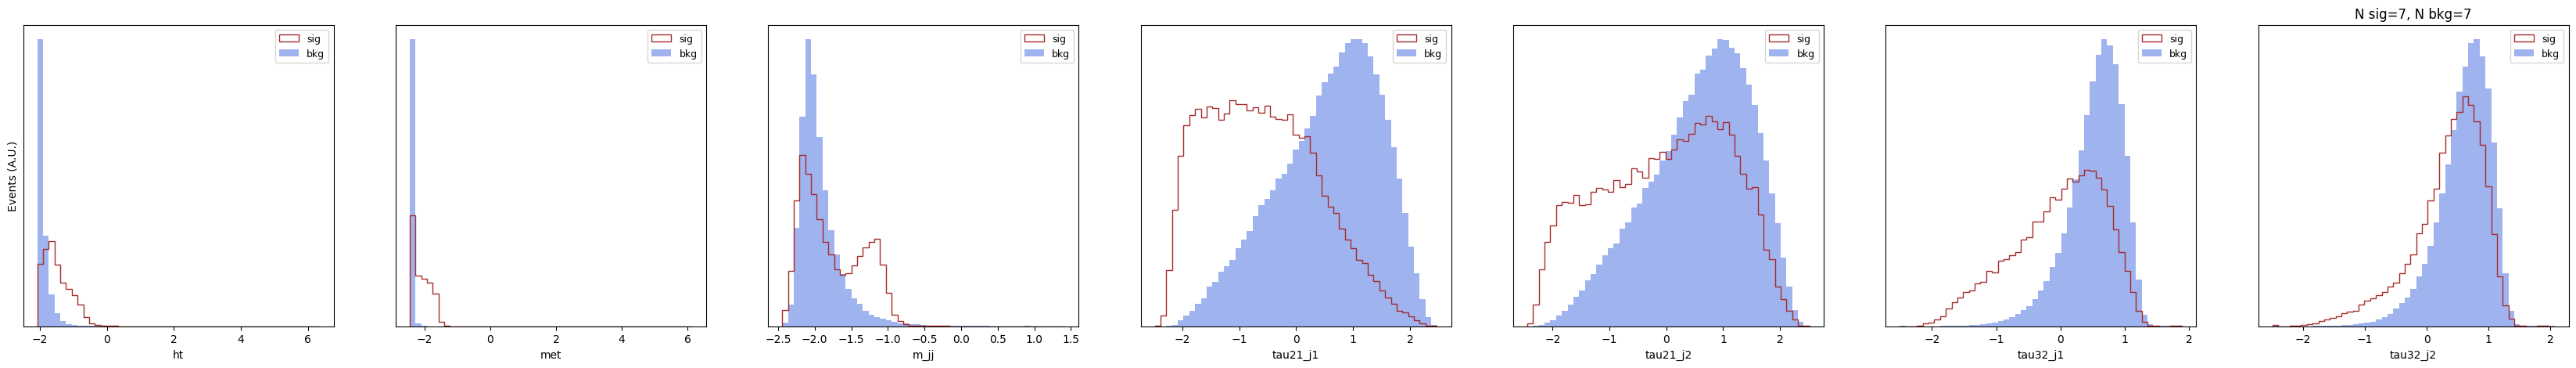

In [2]:
#Path of Test Dataset
test_path = f"{working_dir}/data/test_SR.npz"
#Load Data
test_events = np.load(test_path)
# print(test_events)
sig_list = test_events['sig_events_SR'].T
bkg_list = test_events['bkg_events_SR'].T
var_names = ["ht", "met", "m_jj", "tau21_j1", "tau21_j2", "tau32_j1", "tau32_j2"]
plot_kwargs = {"labels":["sig", "bkg"], "name":f"sig_vs_bkg_test", "title":f"N sig={len(sig_list)}, N bkg={len(bkg_list)}"}
plot_all_variables(sig_list, bkg_list, var_names, **plot_kwargs)

### Signal Injection Graphs

In [3]:
gen_seed = 1

with open(f"{working_dir}/data/mc_scaler.pkl","rb") as f:
    print("Loading in trained minmax scaler.")
    scaler = pickle.load(f)

per = [0, 0.004, 0.009, 0.013, 0.018, 0.022, 0.027]
var_names = ["ht", "met", "m_jj", "tau21_j1", "tau21_j2", "tau32_j1", "tau32_j2"]
#Load Data
data = {}
for p in per:
    data[f"{p}"] = np.load(f"{working_dir}/data/seed{gen_seed}/data_{p}.npz")
    sig_list = data[f"{p}"]["selected_sigs_sr"].T
    bkg_list = data[f"{p}"]["bkg_events_SR"].T
    data_list = scaler.inverse_transform(data[f"{p}"]["data_events_sr"]).T

Loading in trained minmax scaler.


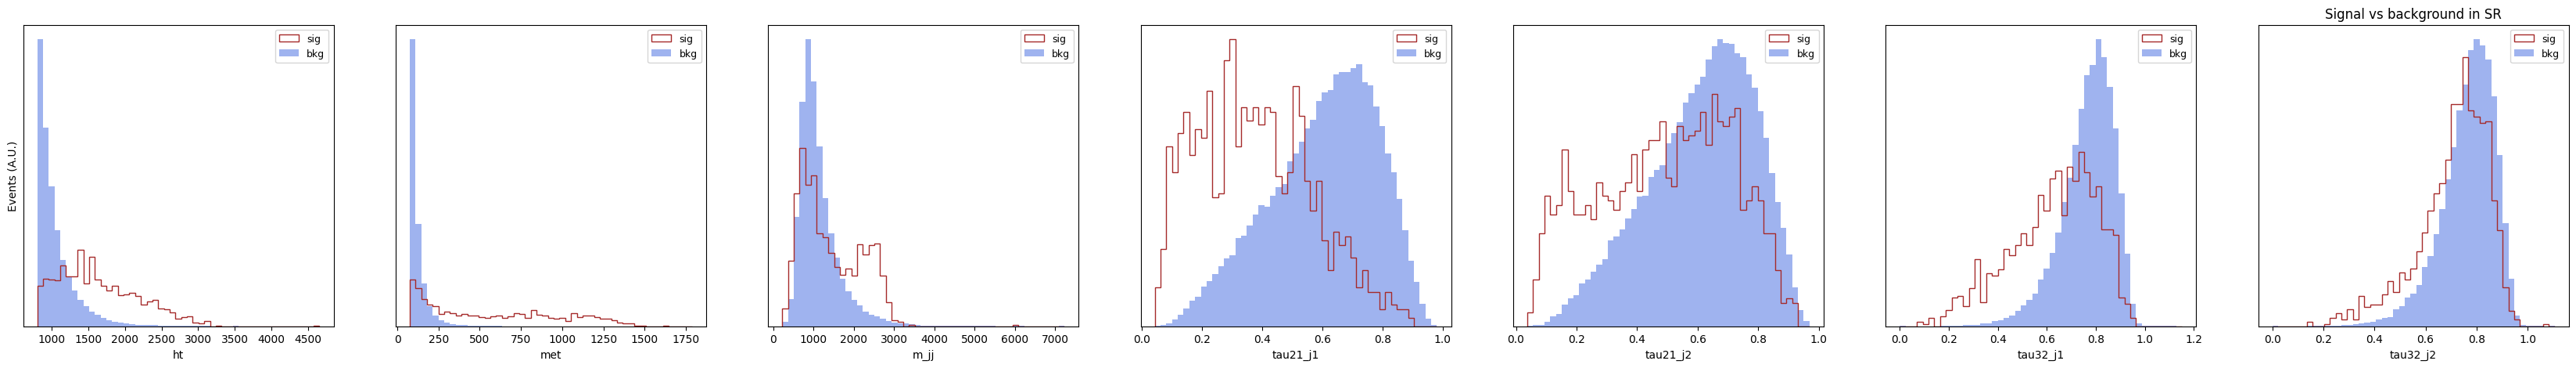

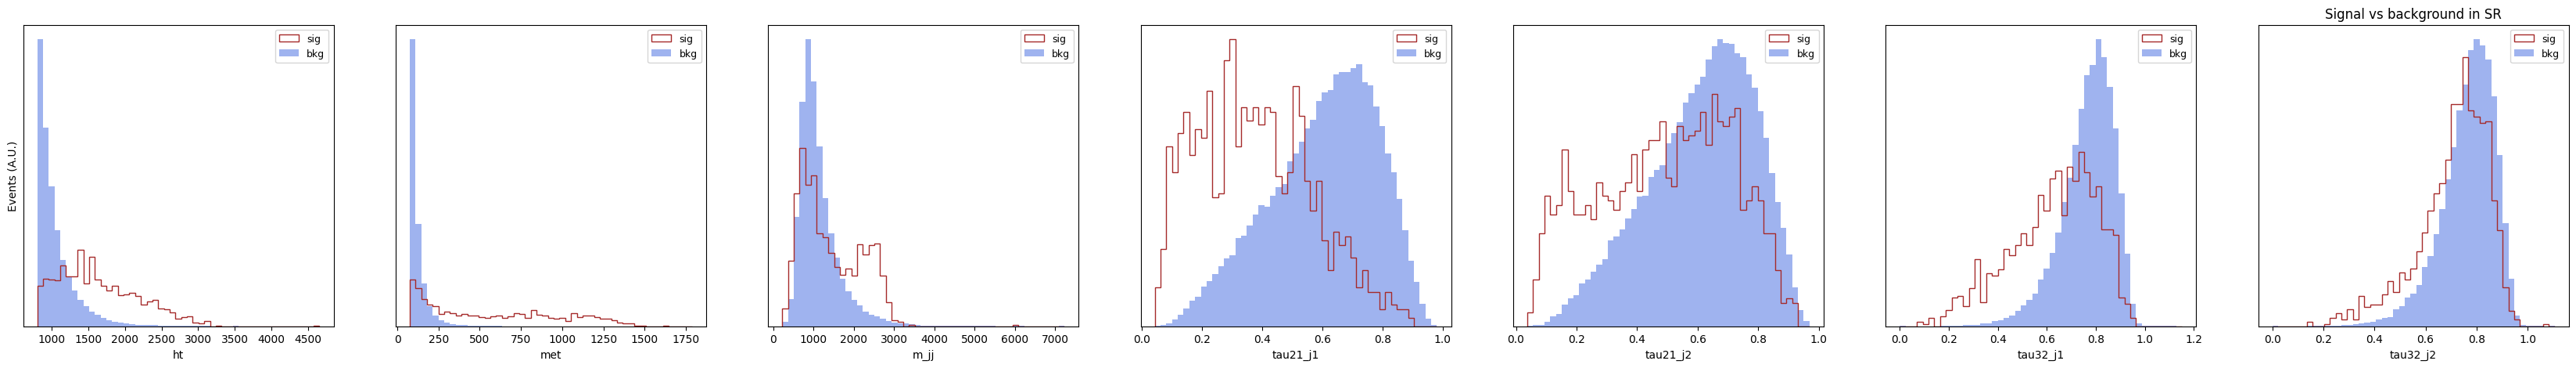

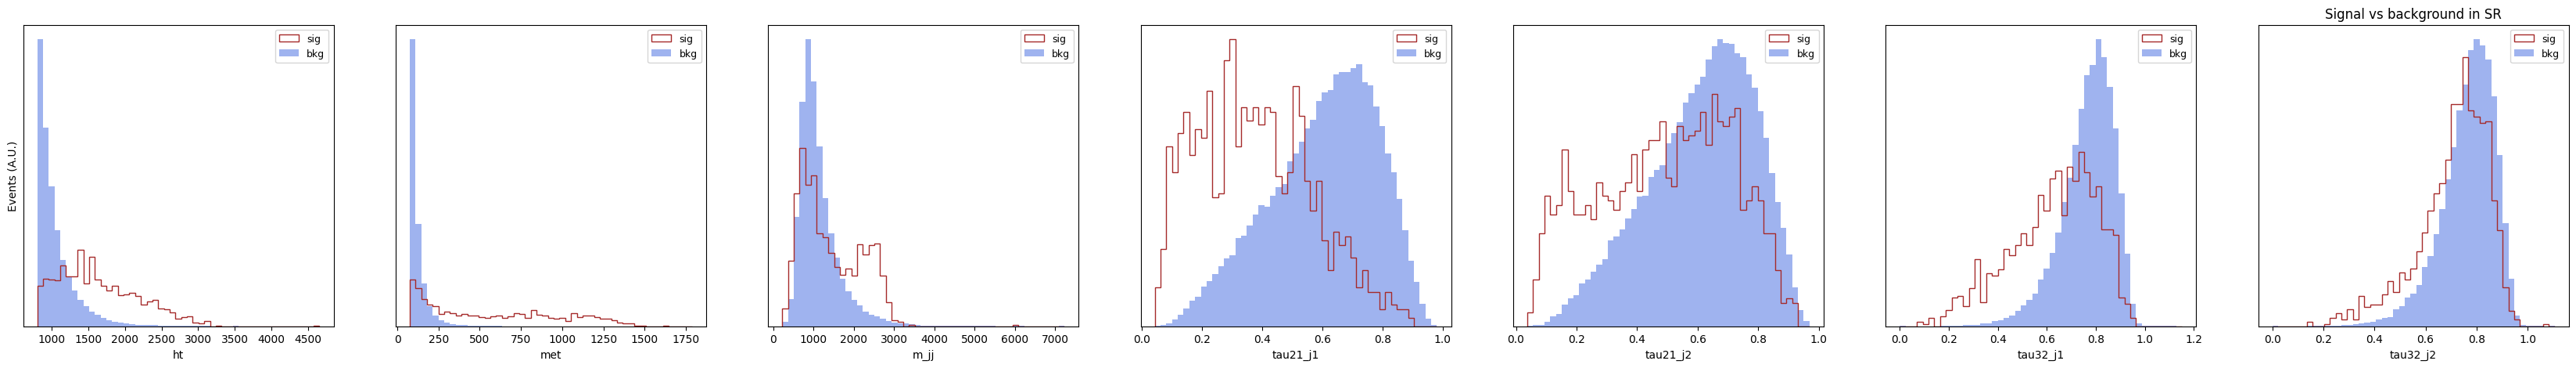

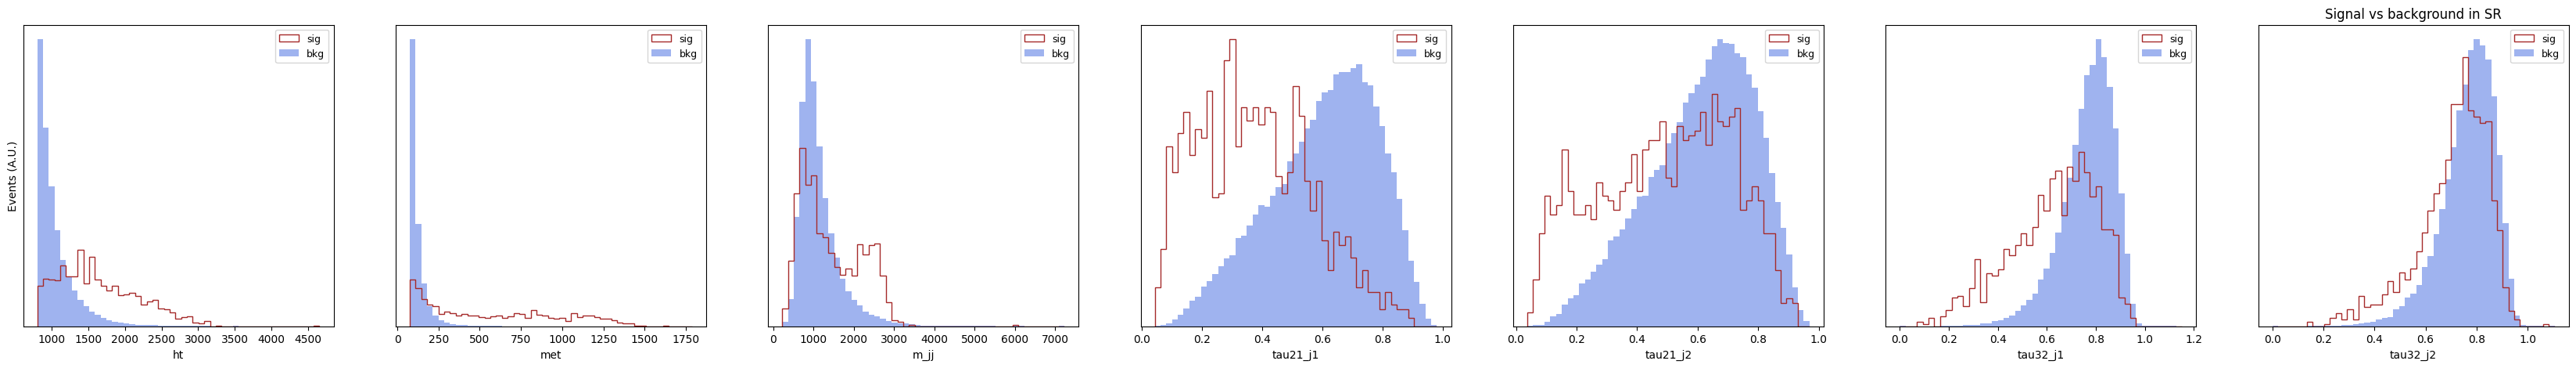

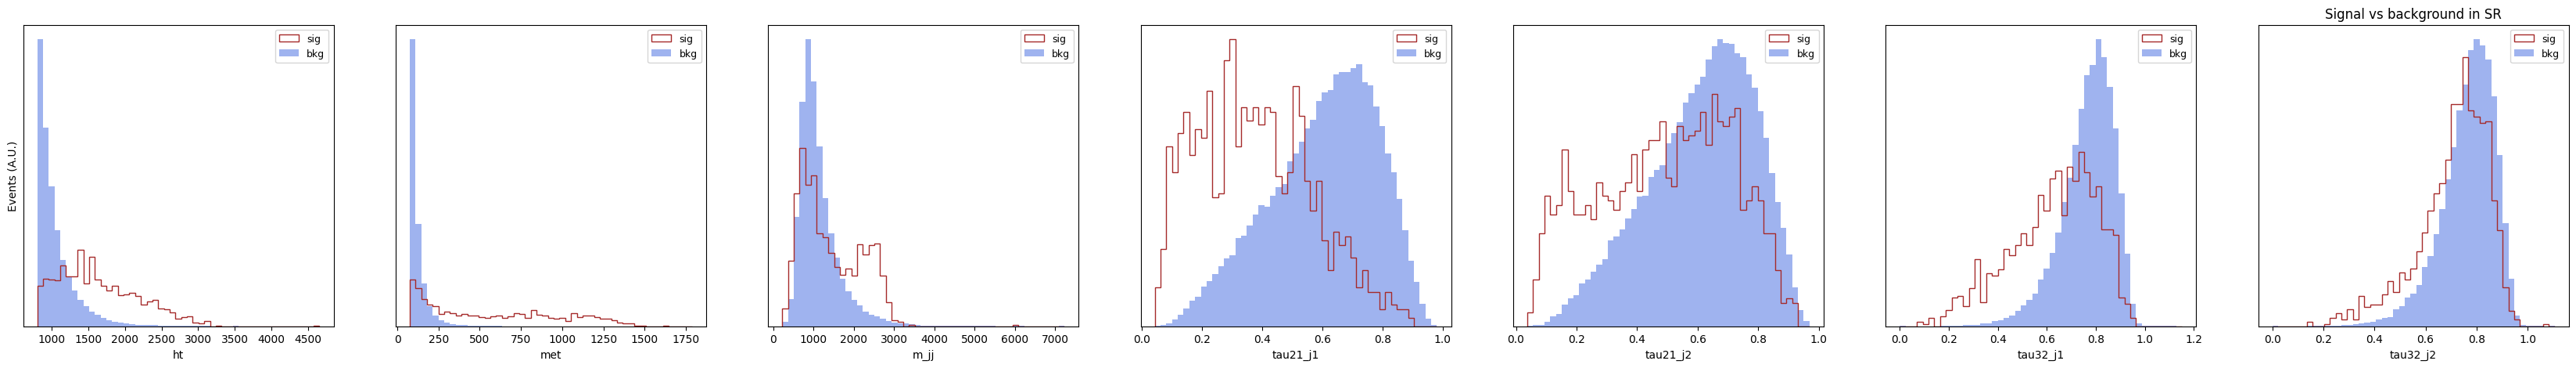

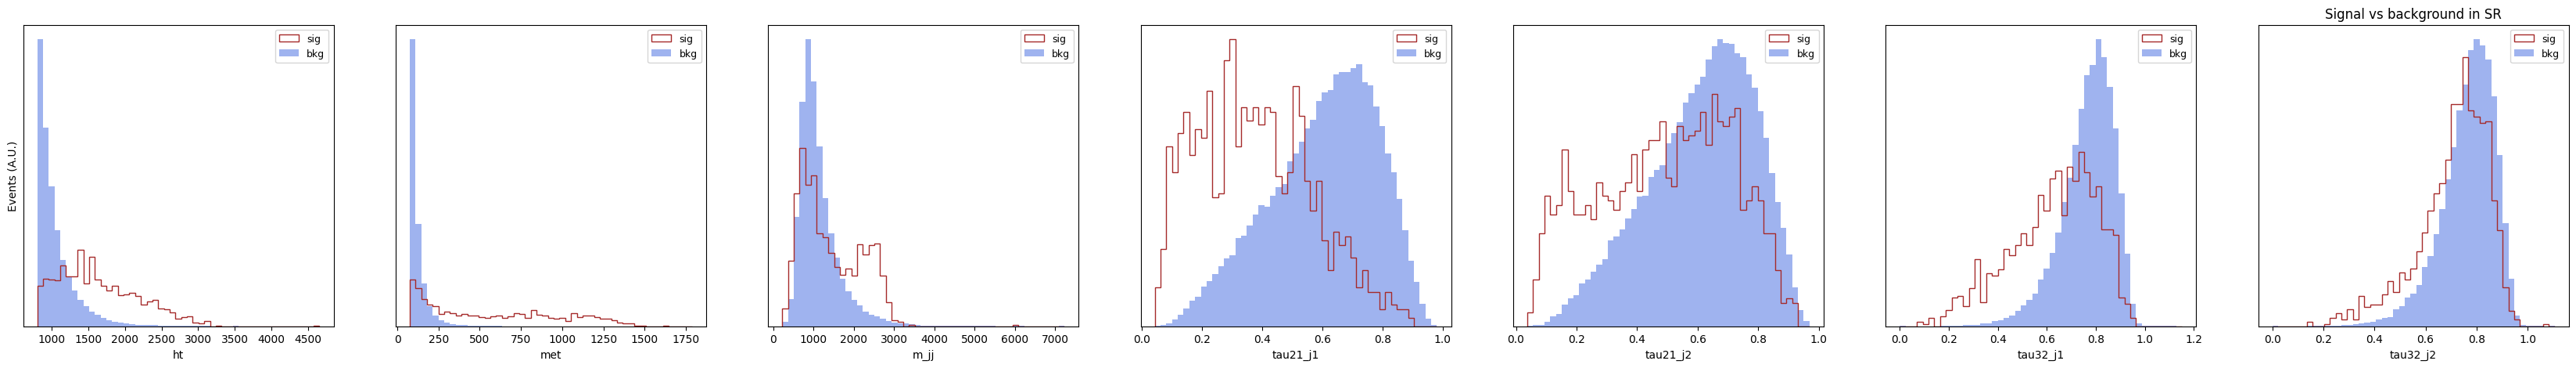

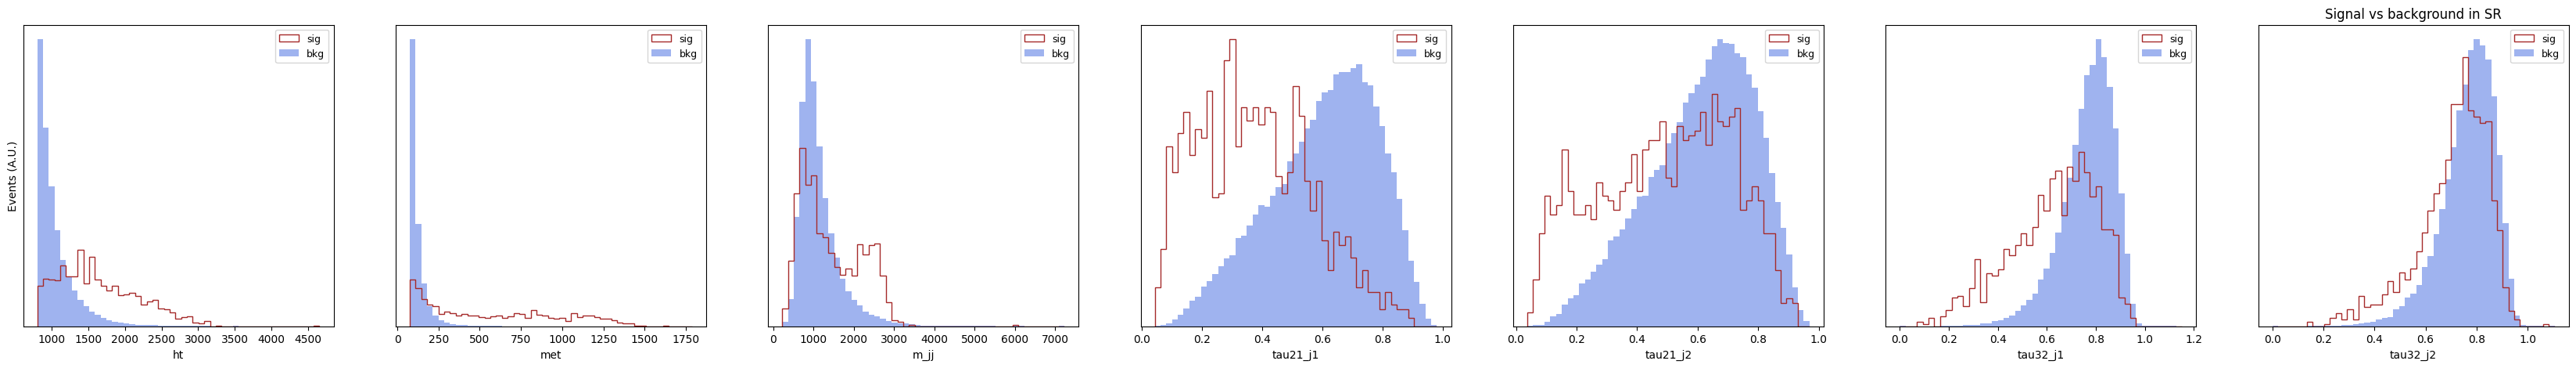

In [4]:
#Signal (SR filtered) vs Background (SR filtered)
for p in per:
    plot_kwargs = {"name":f"sig_vs_bkg_SR_{p}", "title":"Signal vs background in SR"}
    plot_all_variables(sig_list, bkg_list, var_names, **plot_kwargs)

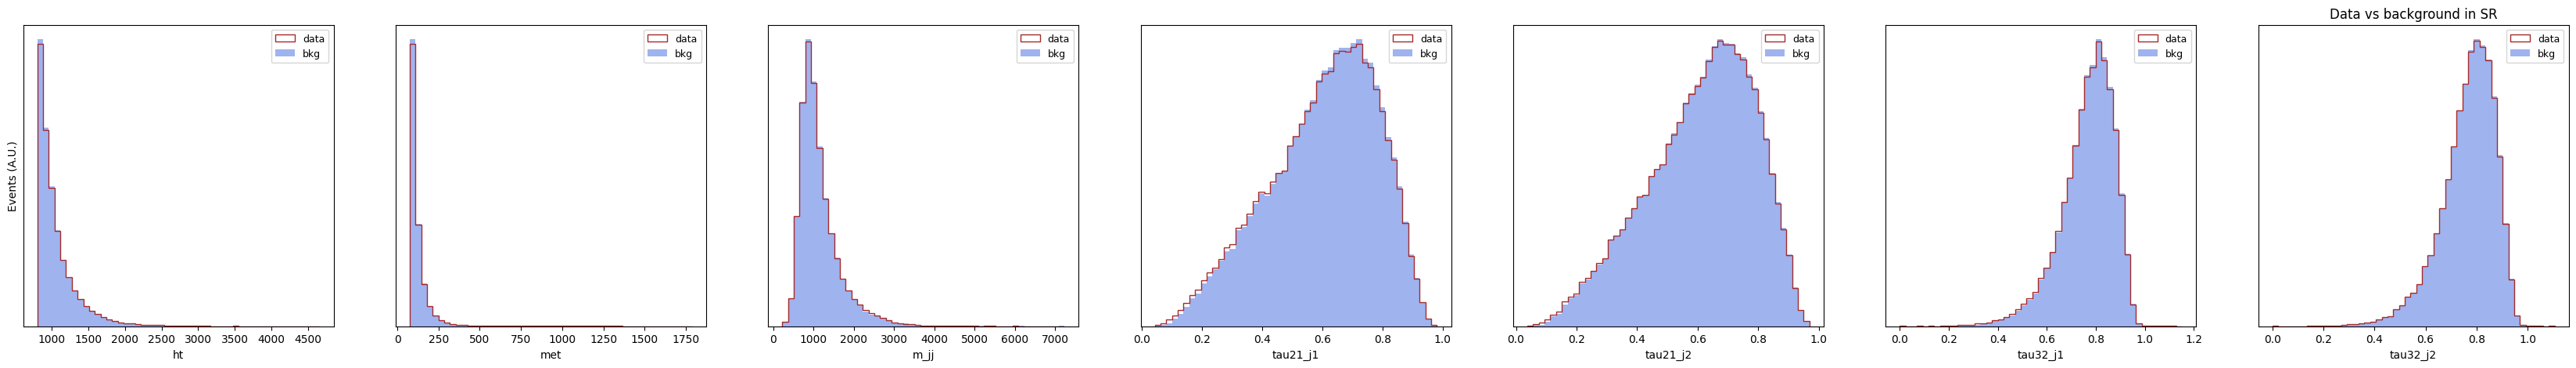

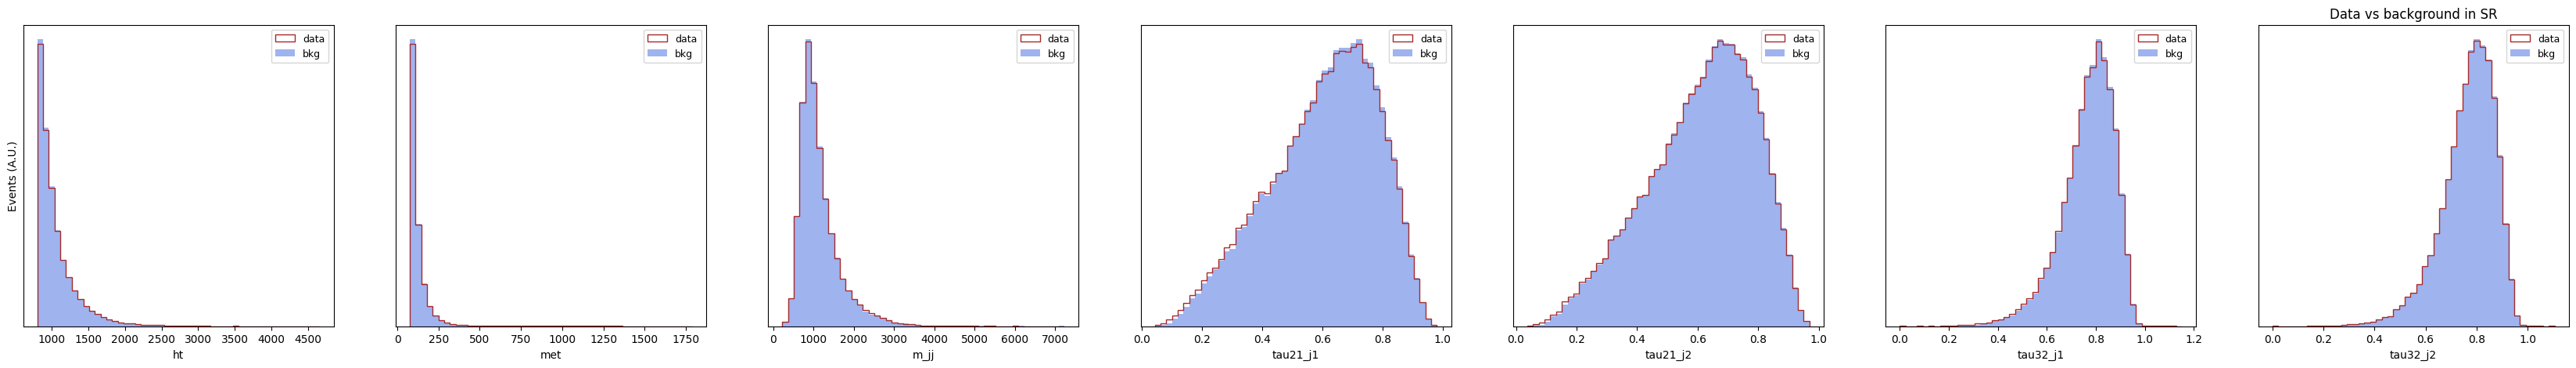

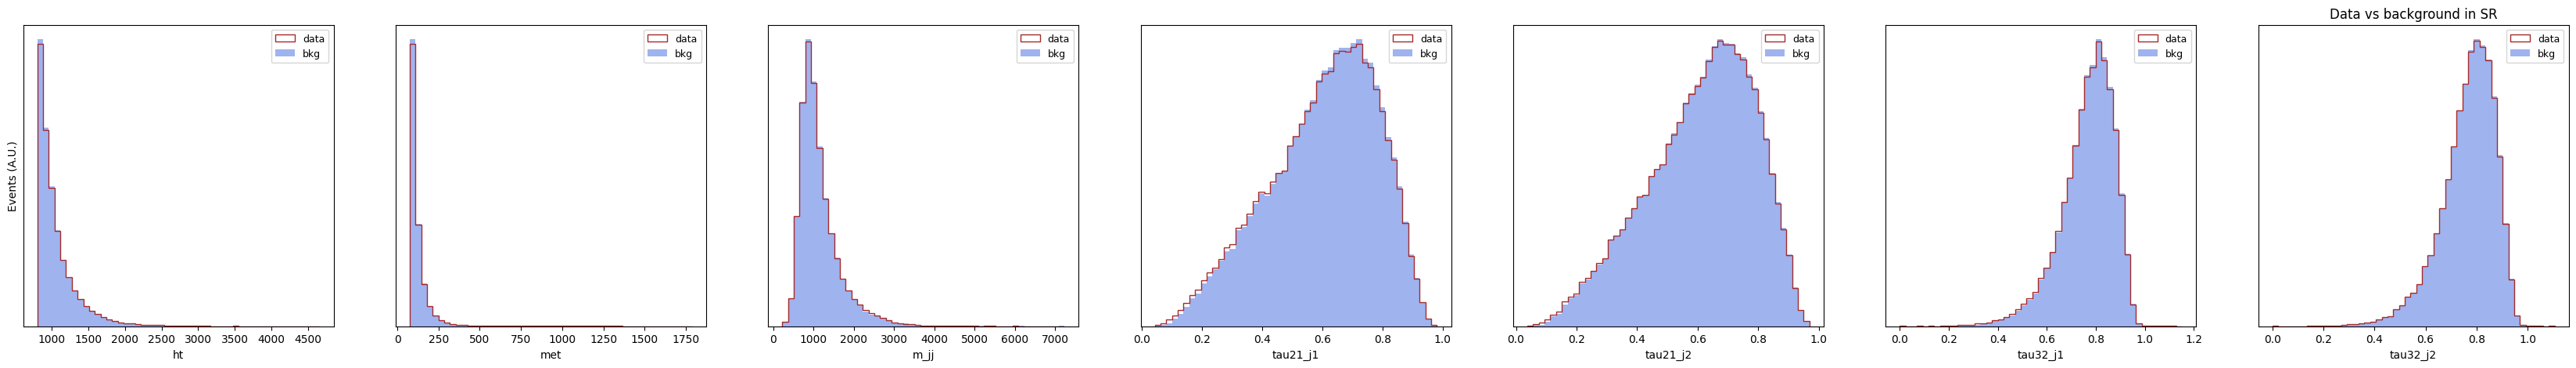

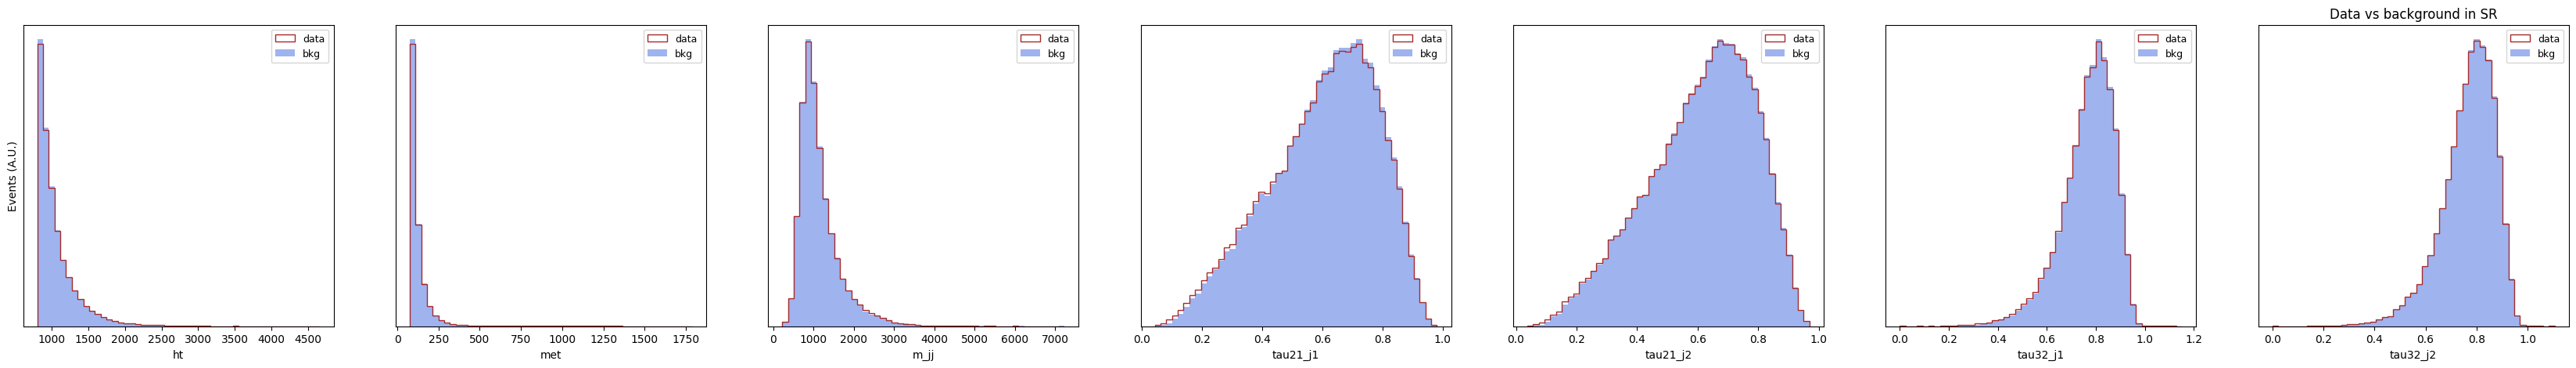

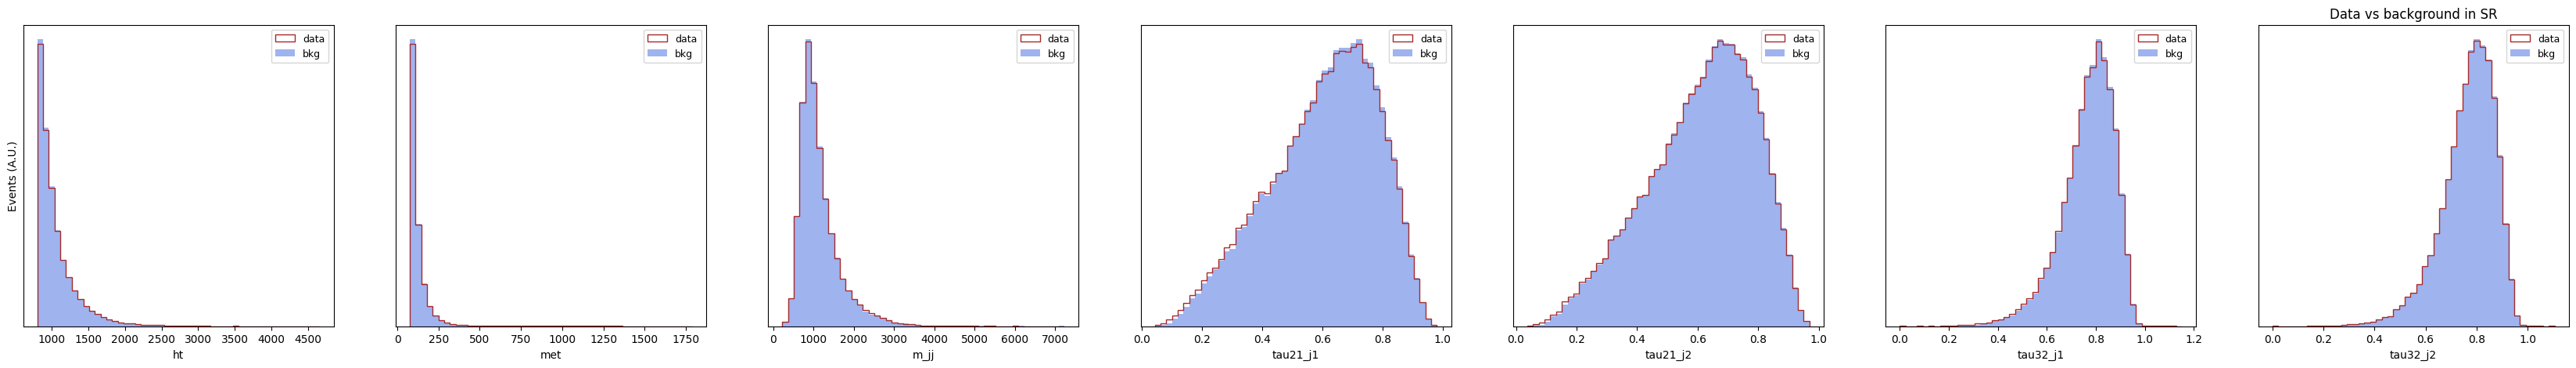

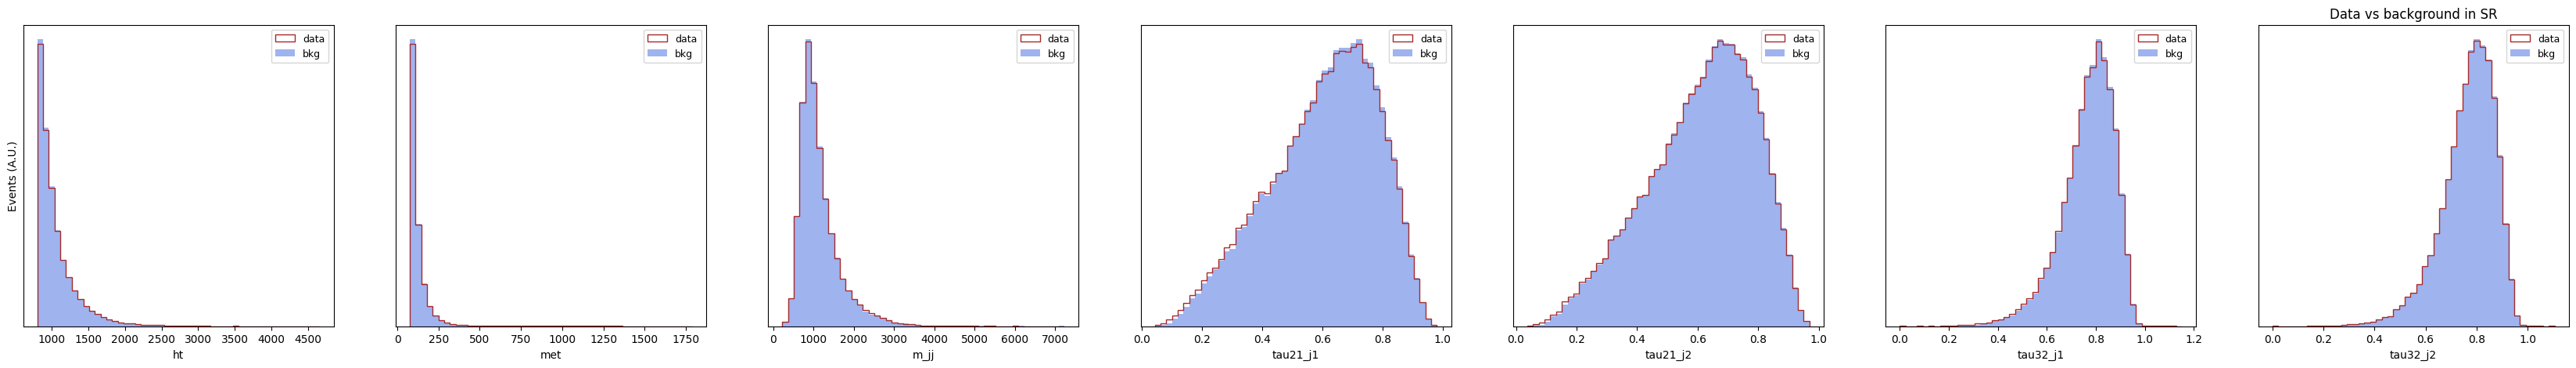

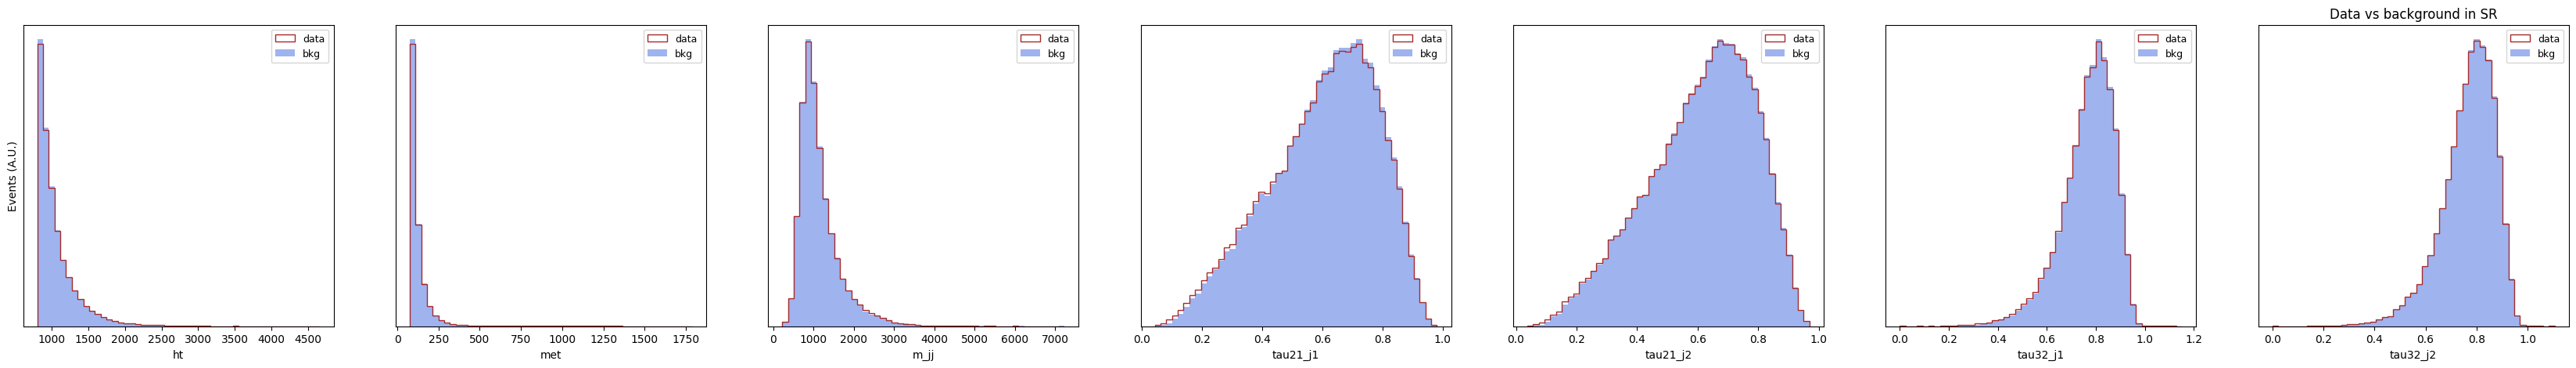

In [5]:
# Data [Bkg + sig] (SR filtered) vs Background (SR filtered)
for p in per:
    plot_kwargs = {"labels":["data", "bkg"], "name":f"data_vs_bkg_SR_{p}", "title":"Data vs background in SR"}
    plot_all_variables(data_list, bkg_list, var_names, **plot_kwargs)

### Model Training

In [20]:
def plot_loss(epochs, train_loss, val_loss, title):
    plt.figure(figsize=(3, 2))
    plt.plot(epochs, train_loss, label="Train Loss", marker='o', linestyle='-', color='blue')
    plt.plot(epochs, val_loss, label="Validation Loss", marker='s', linestyle='--', color='orange')

    plt.title(f"{title}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

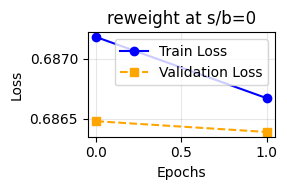

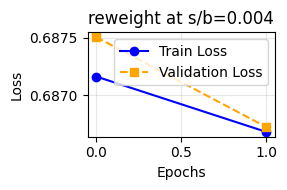

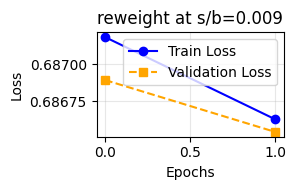

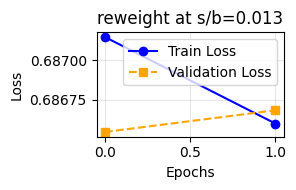

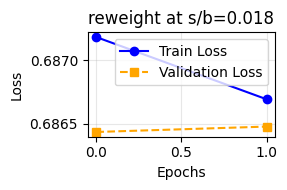

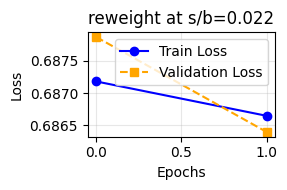

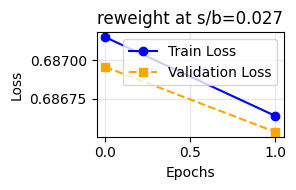

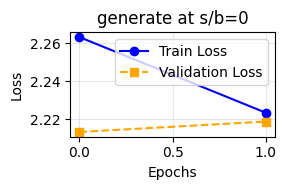

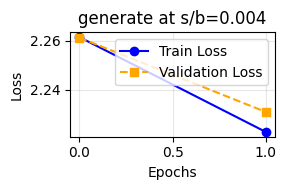

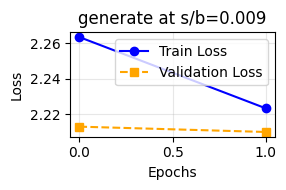

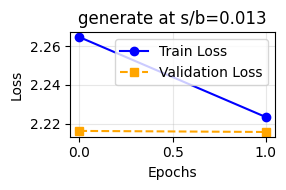

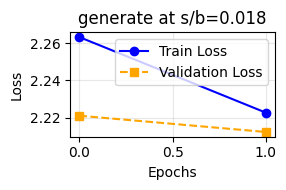

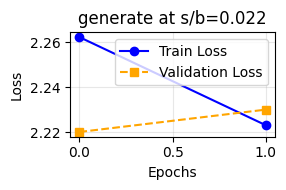

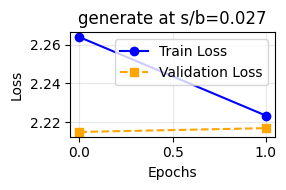

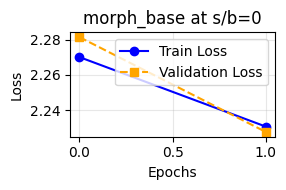

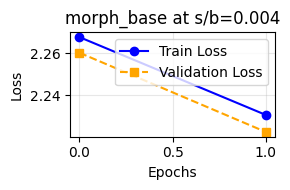

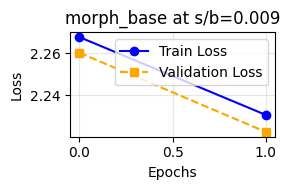

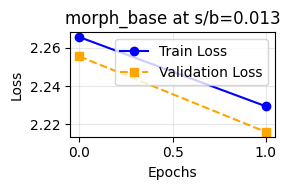

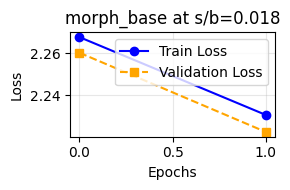

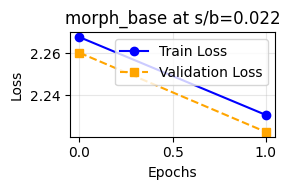

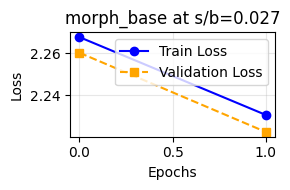

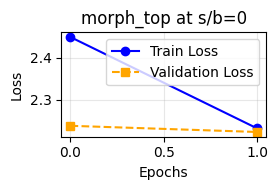

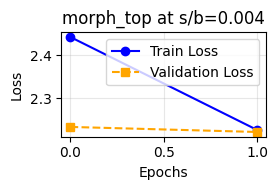

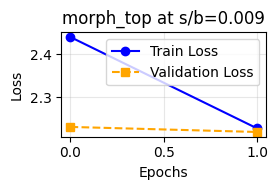

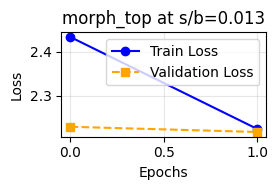

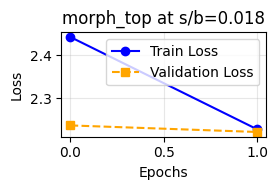

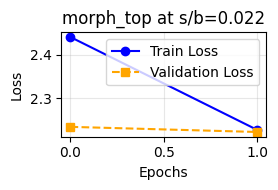

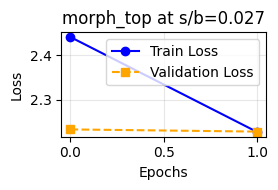

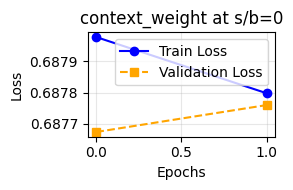

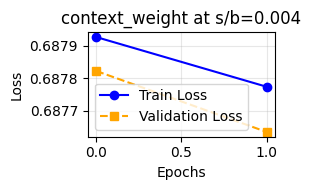

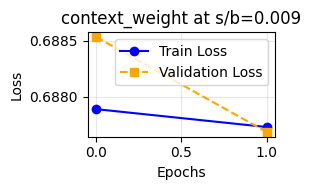

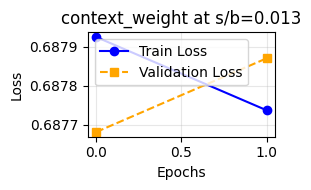

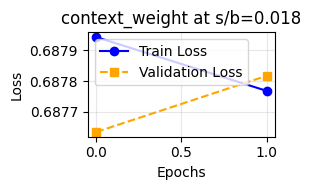

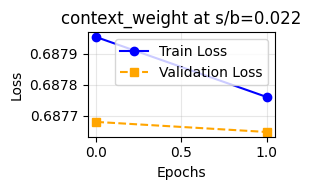

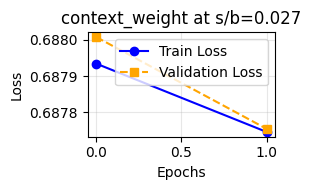

In [21]:
gen_seed = 1
models = ['reweight','generate','morph_base','morph_top','context_weight']

#Paths
loss_path = f"{working_dir}/models/seed{gen_seed}/loss_data"
Loss_Data = {}
for model in models:
    for p in per:
        Loss_Data[f"{model}_{p}"] = np.load(f"{loss_path}/{model}_{p}_loss.npz")
        plot_loss(Loss_Data[f"{model}_{p}"]["epochs"], Loss_Data[f"{model}_{p}"]["train_loss"], Loss_Data[f"{model}_{p}"]["val_loss"], f"{model} at s/b={p}")
        
        

### Model Metrics

In [ ]:
#Washerstein Distances


### Sample Generation (Closure Test)

In [24]:
#Sample Path
samples_path = f"{working_dir}/samples/"
# Data Path for Truth
data_path = f"{working_dir}/data/"
gen_seed = 1
n_context = 2
n_samples = 30000
models = ['reweight','generate','morph', 'context_weight']
#Load all Data
CR_Data = {}
SR_Data = {}
for p in per:
    for model in models:
        CR_Data[f"{model}_{p}_cr"] = np.load(f"{samples_path}/seed{gen_seed}/{model}_CR_samples_{p}.npz")
        SR_Data[f"{model}_{p}_sr"] = np.load(f"{samples_path}/seed{gen_seed}/{model}_SR_samples_{p}.npz")

samples_cr_dict = {}
samples_sr_dict = {}
weights_cr_dict = {}
weights_sr_dict = {}

In [45]:
for p in per:
    samples_cr_dict[f"truth_{p}"] = np.load(f"{data_path}/seed{gen_seed}/data_{p}.npz")["data_events_cr"][:n_samples,n_context:]
    weights_cr_dict[f"truth_{p}"] = None
    samples_sr_dict[f"truth_{p}"] = np.load(f"{data_path}/seed{gen_seed}/data_{p}.npz")["data_events_sr"][:n_samples,n_context:]
    weights_sr_dict[f"truth_{p}"] = None
    for model in ['reweight', 'generate', 'morph']:
        if model == 'reweight':
            samples_cr_dict[f"{model}_{p}"] = CR_Data[f"{model}_{p}_cr"]["mc_cr"][:,n_context:]
            weights_cr_dict[f"{model}_{p}"] = CR_Data[f"context_weight_{p}_cr"]["w_cr"]
            samples_sr_dict[f"{model}_{p}"] = SR_Data[f"{model}_{p}_sr"]["mc_samples"][:,n_context:]
            weights_sr_dict[f"{model}_{p}"] = SR_Data[f"context_weight_{p}_sr"]["w_sr"]
        elif model == 'generate':
            samples_cr_dict[f"{model}_{p}"] = CR_Data[f"{model}_{p}_cr"][f"{model}_cr"]
            weights_cr_dict[f"{model}_{p}"] = None
            samples_sr_dict[f"{model}_{p}"] = SR_Data[f"{model}_{p}_sr"]["samples"]
            weights_sr_dict[f"{model}_{p}"] = None
        elif model == 'morph':
            samples_cr_dict[f"{model}_{p}"] = CR_Data[f"{model}_{p}_cr"][f"{model}_cr"]
            weights_cr_dict[f"{model}_{p}"] = CR_Data[f"context_weight_{p}_cr"]["w_cr"]
            samples_sr_dict[f"{model}_{p}"] = SR_Data[f"{model}_{p}_sr"]["samples"]
            weights_sr_dict[f"{model}_{p}"] = SR_Data[f"context_weight_{p}_sr"]["w_sr"]

In [35]:
#Graph Part
#Labels and stuff
def name_map():
    return {
        "m_jj": "$m_{{\\rm jj}}$",
        "met": "MET",
        "ht": "HT",
        "pT_j1": "Leading jet $p_{{\\rm T}}$",
        "pT_j2": "Sub-leading jet $p_{{\\rm T}}$",
        "tau21_j1": "Leading jet $\\tau_2/\\tau_1$",
        "tau21_j2": "Sub-leading jet $\\tau_2/\\tau_1$",
        "tau32_j1": "Leading jet $\\tau_3/\\tau_2$",
        "tau32_j2": "Sub-leading jet $\\tau_3/\\tau_2$",
        "min_dPhi": "min$\\Delta\\phi(\\rm j_i, \\rm MET)$",
    }

var_names = ["m_jj", "tau21_j1", "tau21_j2", "tau32_j1", "tau32_j2"]
names = name_map()

xlabel_list = [] 
for x in var_names:
    xlabel_list.append(f"{names[x]}")

colors_dict = {}
#Gen_color_dicts
for p in per:
    colors_dict[f"reweight_{p}"] = "forestgreen"
    colors_dict[f"morph_{p}"] = "mediumvioletred"
    colors_dict[f"generate_{p}"] = "darkgoldenrod"
    colors_dict[f"truth_{p}"] = "lightblue"
bins = np.linspace(-3, 3, 30)
bin_centers = 0.5*(bins[1:] + bins[:-1] )

f1 = 24
f2 = 20

n_features = 5

In [51]:
def plot_samples(samples, weights, bins, colors_dict, keys_to_plot, xlabel_list, bin_centers, n_features, f1, f2, p):
    # Ignore warnings for division or invalid operations
    np.seterr(divide='ignore', invalid='ignore')

    # Create a grid of subplots
    fig, ax = plt.subplots(2, n_features, figsize=(5 * n_features, 1.5 * n_features), height_ratios=[2, 1])

    for i in range(n_features):
        # Plot "truth" histogram
        truth_density, _, _ = ax[0, i].hist(
            samples[f"truth_{p}"][:, i],
            color=colors_dict[f"truth_{p}"],
            bins=bins,
            label="Truth (bkg)",
            density=True
        )
        hist_denom, _ = np.histogram(samples[f"truth_{p}"][:, i], bins=bins, density=False)
        errors_denom = np.sqrt(hist_denom)
        ax[0, i].set_xlim(-3, 3)

        # Plot histograms for other datasets and compute ratios
        for k in keys_to_plot:
            loc_density, _, _ = ax[0, i].hist(
                samples[k][:, i],
                bins=bins,
                label=k,
                histtype="step",
                density=True,
                color=colors_dict[k],
                lw=2,
                weights=weights[k]
            )
            loc_hist, _ = np.histogram(samples[k][:, i], bins=bins, density=False, weights=weights[k])

            loc_errors = np.sqrt(loc_hist)
            loc_ratio = loc_density / truth_density
            loc_errors_ratio = np.sqrt(
                (errors_denom / hist_denom) ** 2 + (loc_errors / loc_hist) ** 2
            ) * loc_ratio
            ax[1, i].errorbar(
                bin_centers, loc_ratio, yerr=loc_errors_ratio, linestyle="", color=colors_dict[k], capsize=2
            )

        # Configure x-axis labels and ratio line
        ax[1, i].set_xlabel(xlabel_list[i], fontsize=f1)
        ax[1, i].axhline(1, color="black", linestyle="dashed")
        ax[1, i].set_xlim(-2.5, 2.5)
        ax[1, i].set_xticks(np.arange(-2, 3, 1))
        ax[1, i].set_ylim(0, 2)

    # Configure y-axis labels
    ax[0, 0].set_ylabel("a.u.", fontsize=f1, labelpad=50)
    ax[0, 0].set_yticks([])
    ax[1, 0].set_ylabel("Ratio to \ntruth", fontsize=f1)

    # Remove y-ticks for other plots
    for i in range(1, n_features):
        ax[0, i].set_yticks([])
        ax[1, i].set_yticks([])

    # Add legend
    ax[0, 0].legend(frameon=False, fontsize=f2)

    # Adjust layout
    plt.subplots_adjust(wspace=0, hspace=0)

    # Show the plot in the notebook
    plt.show()


CR Closure


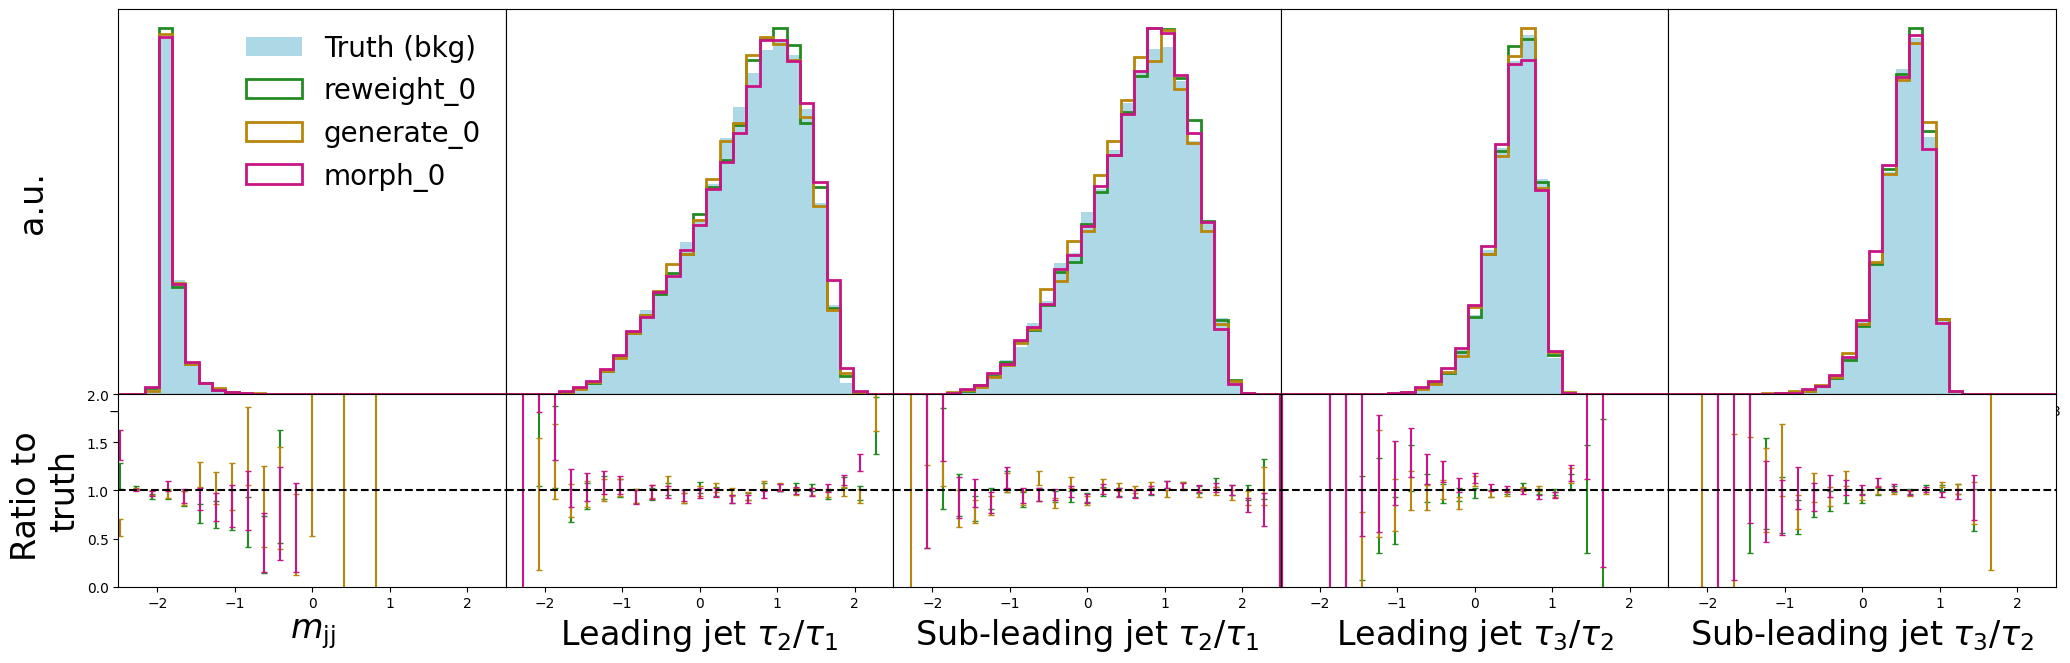

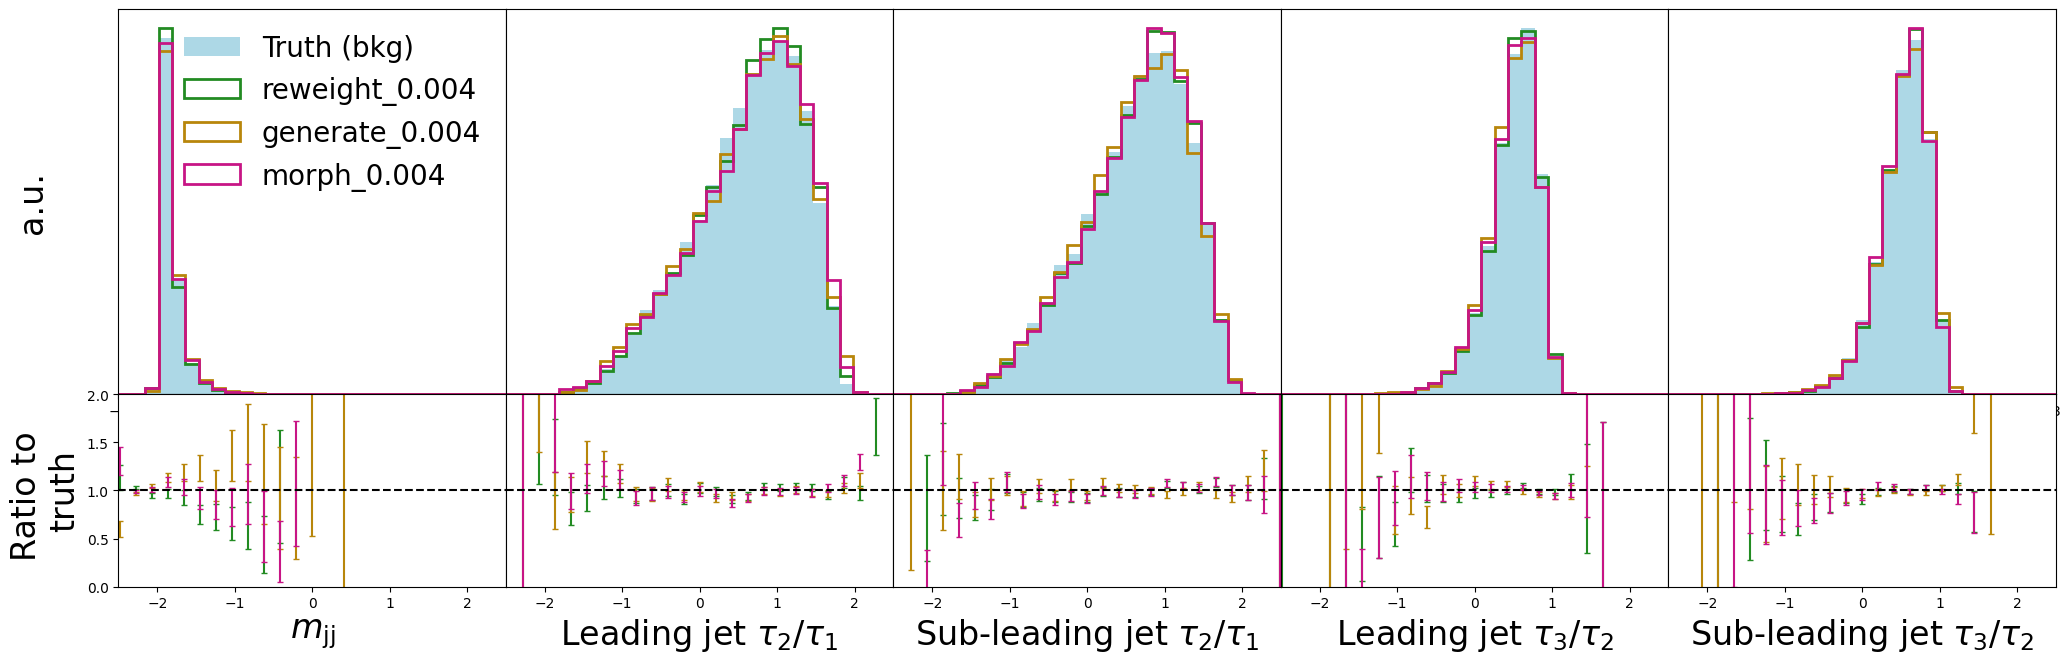

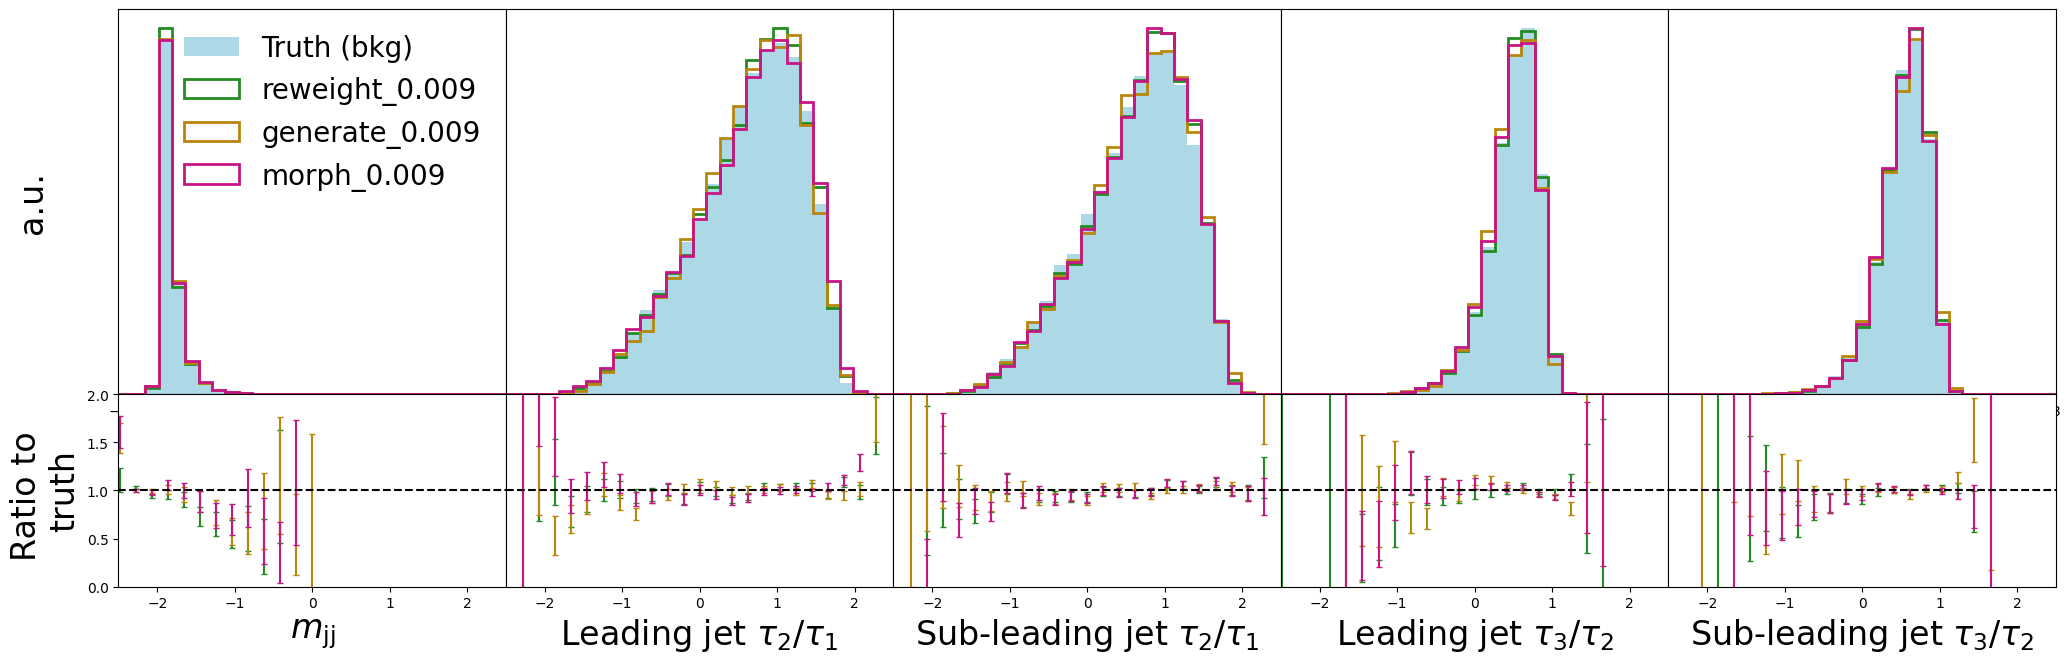

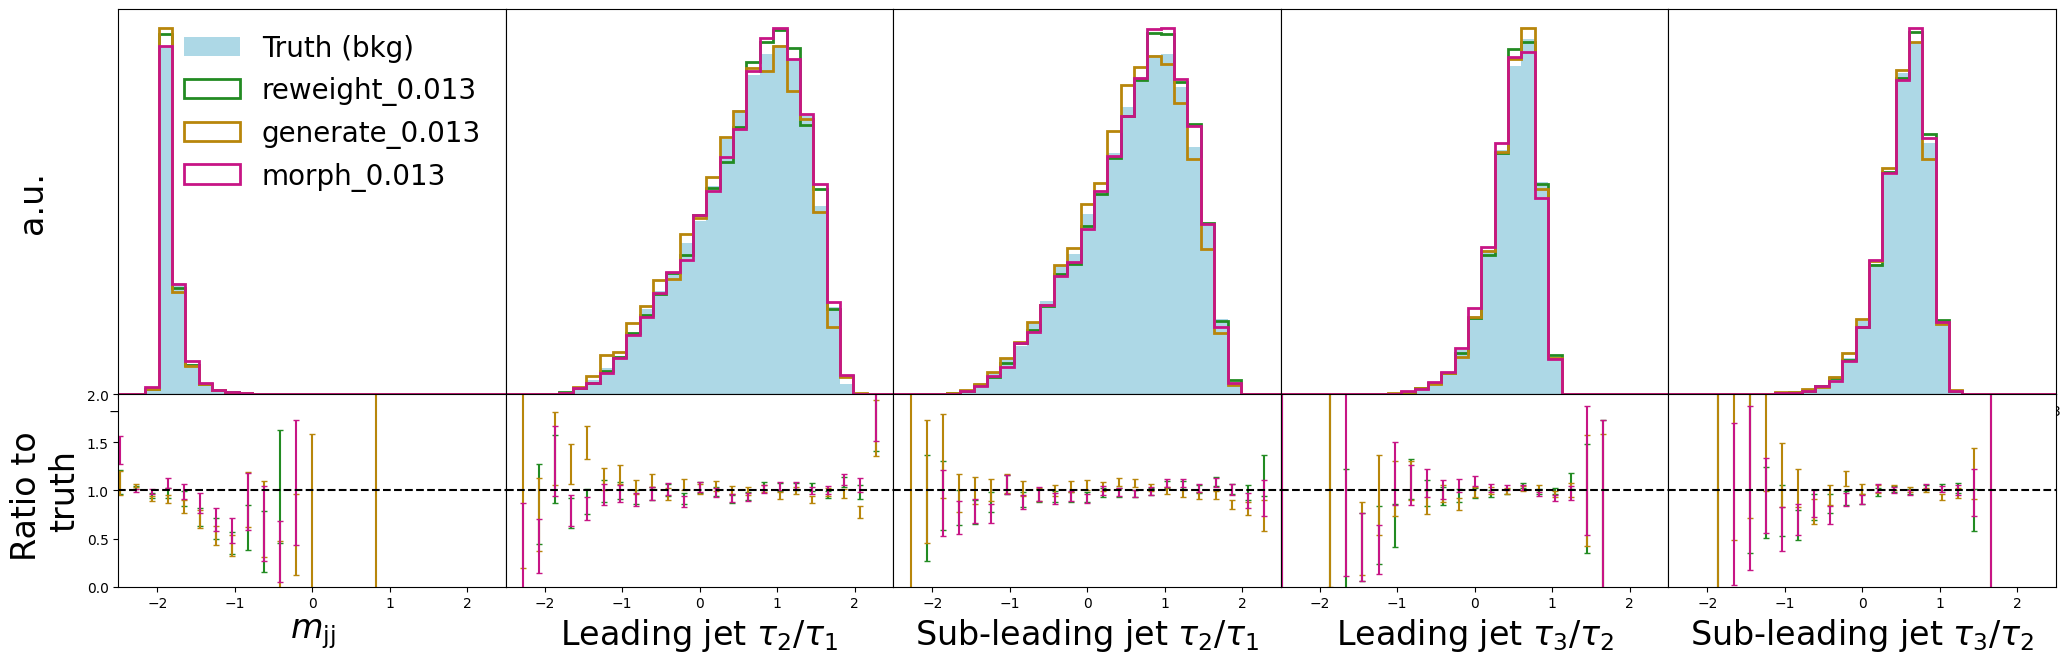

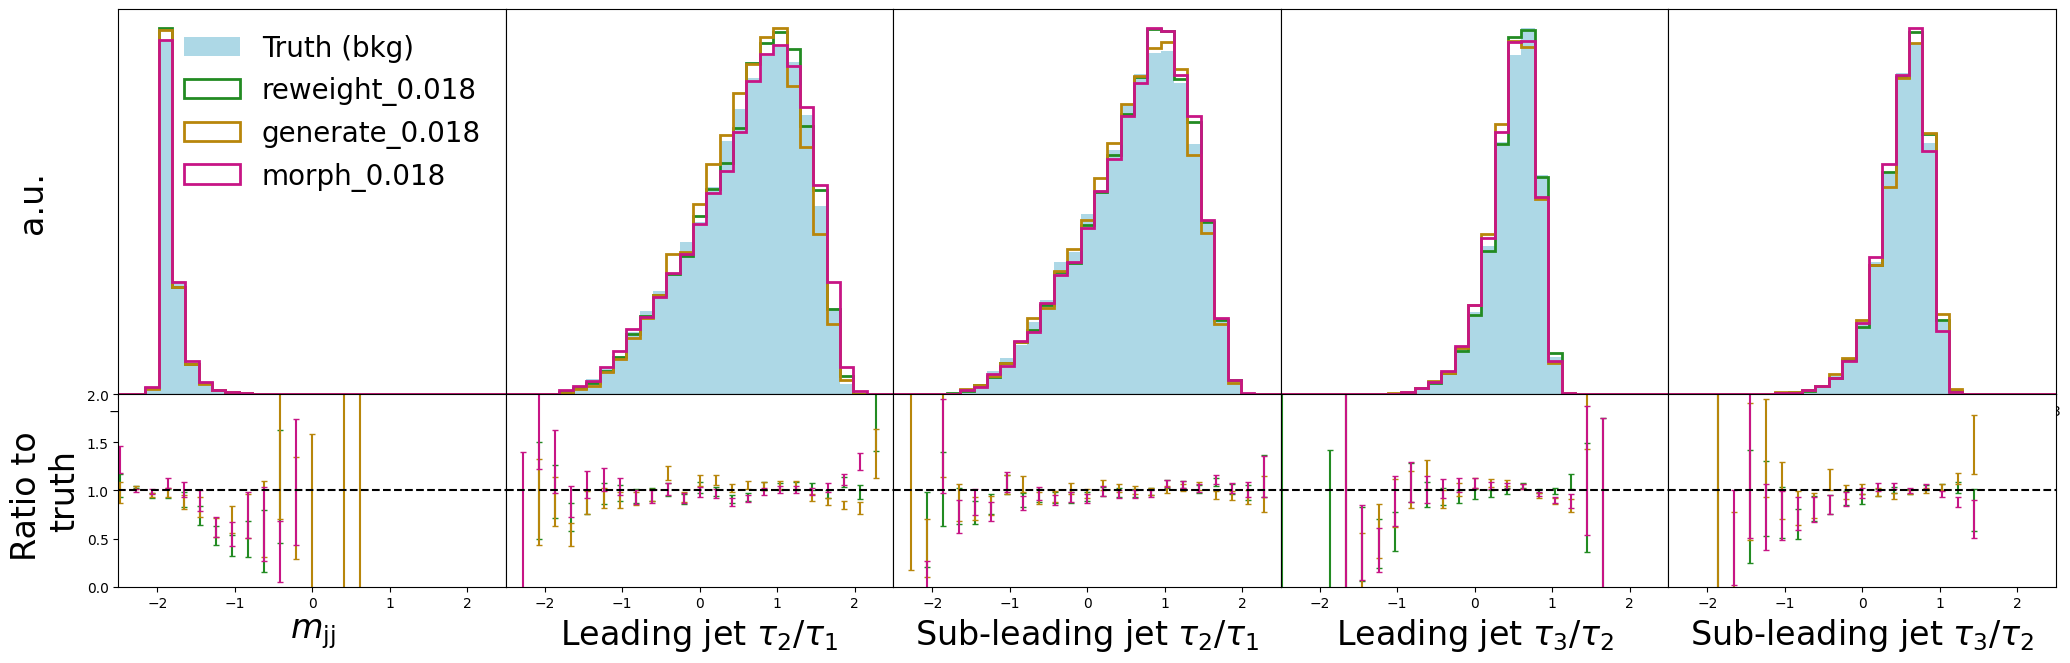

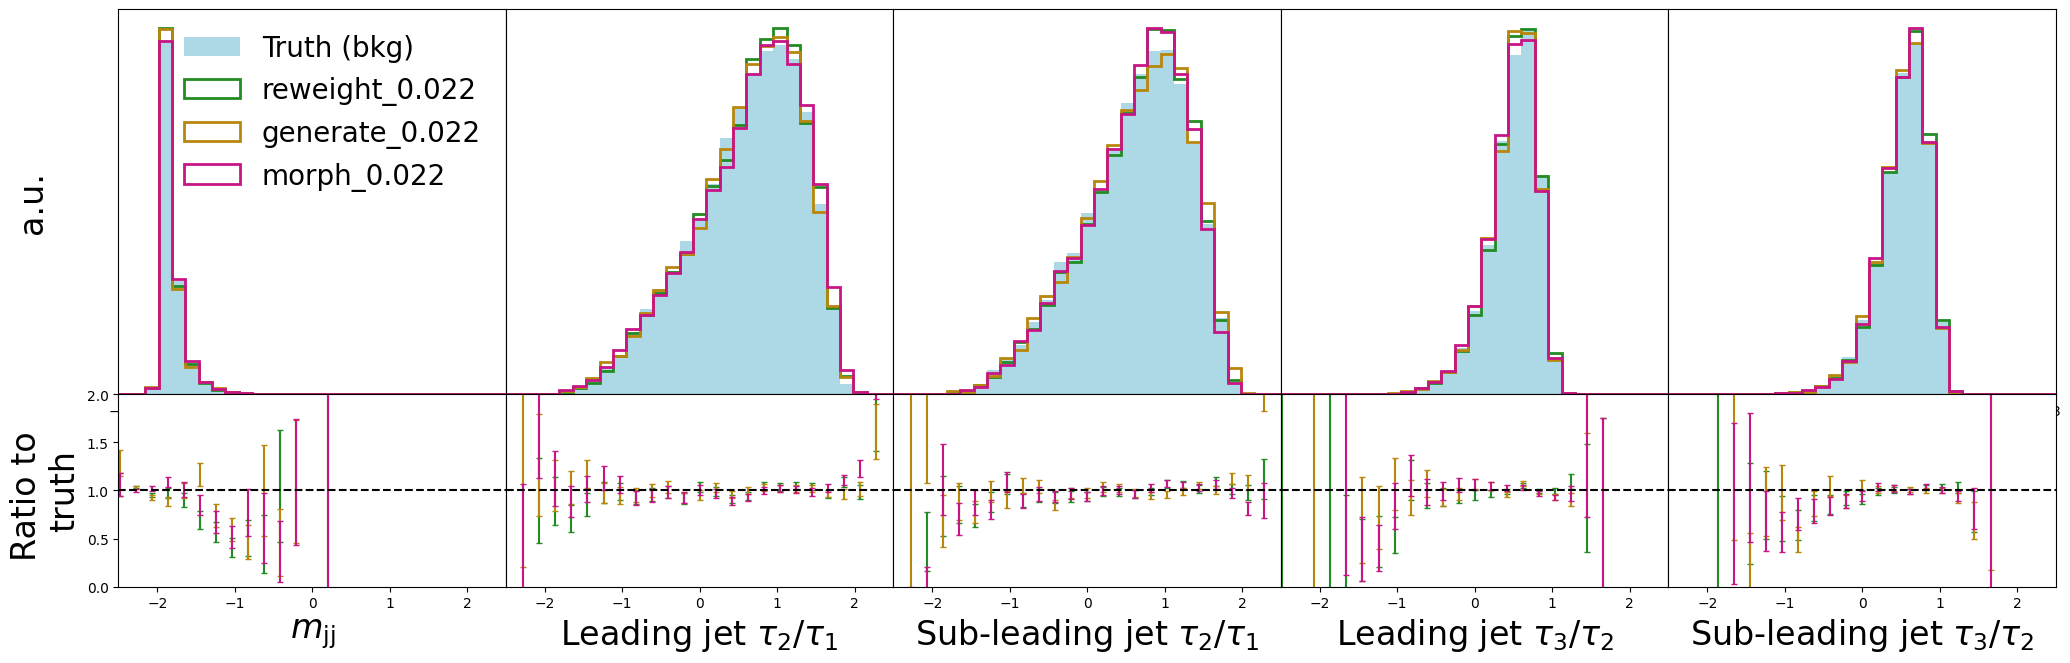

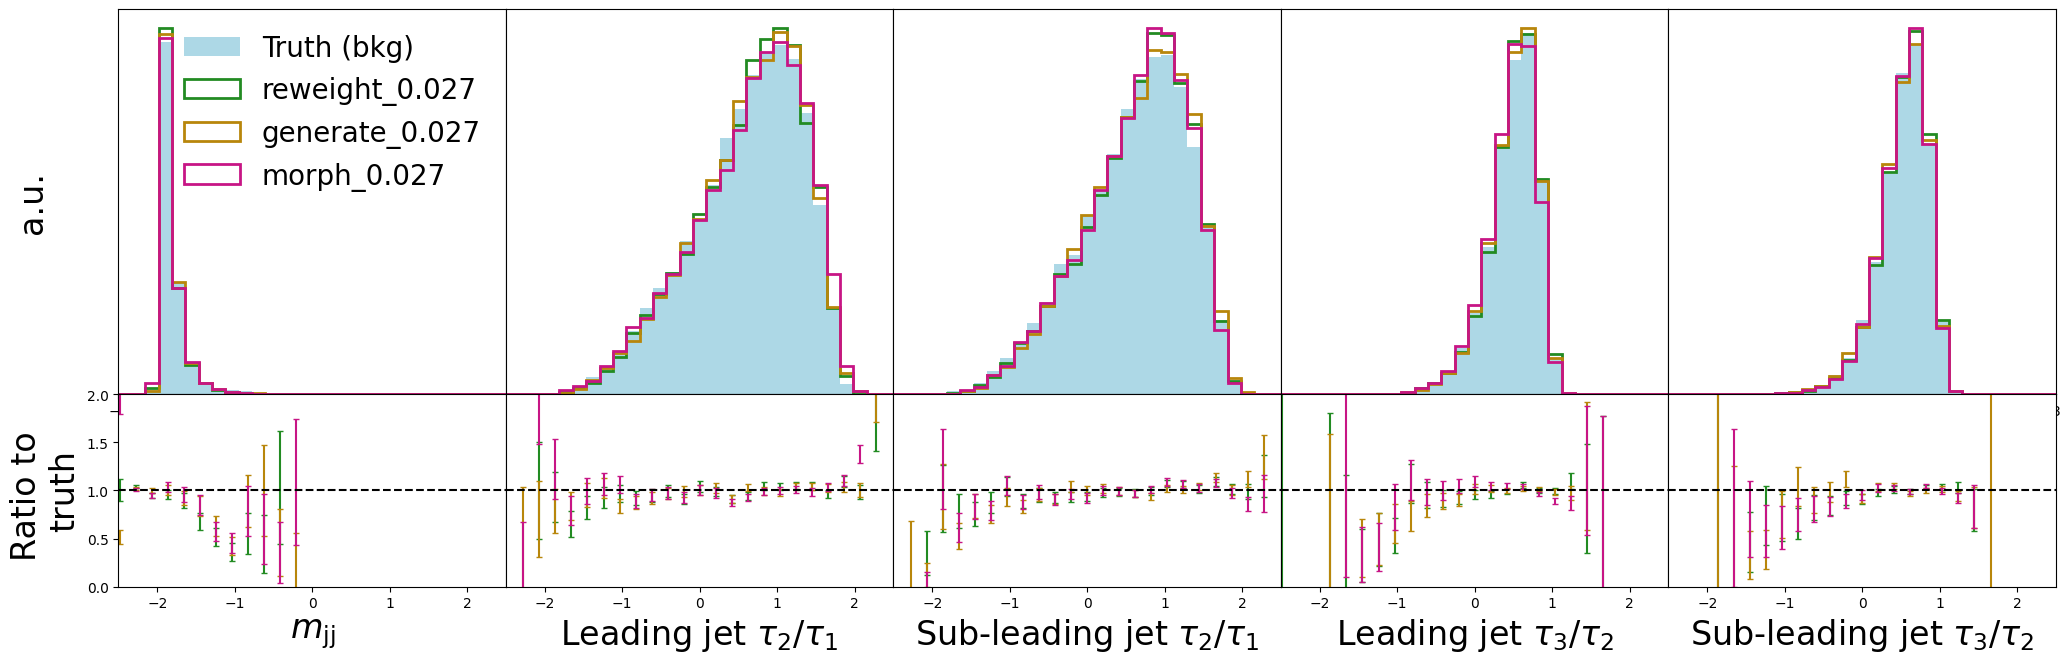

In [53]:
print("CR Closure")
for p in per:
#     keys_to_plot = [f"generate_{p}", f"morph_{p}"]
    keys_to_plot = [f"reweight_{p}", f"generate_{p}",f"morph_{p}"]
    plot_samples(samples_cr_dict, weights_cr_dict, bins, colors_dict, keys_to_plot, xlabel_list, bin_centers, n_features, f1, f2, p)

SR Closure


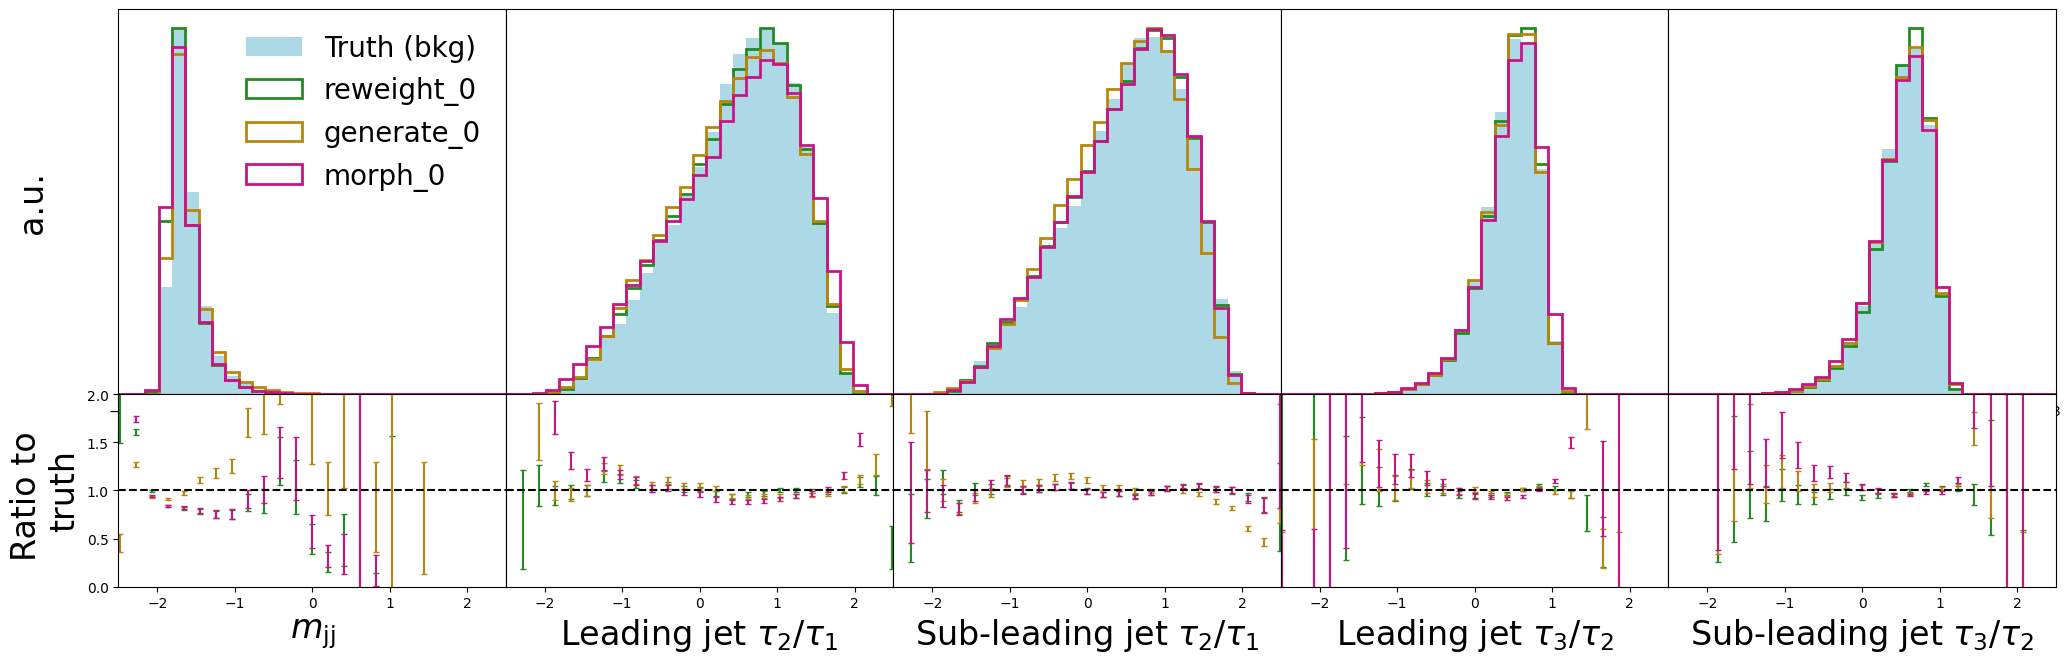

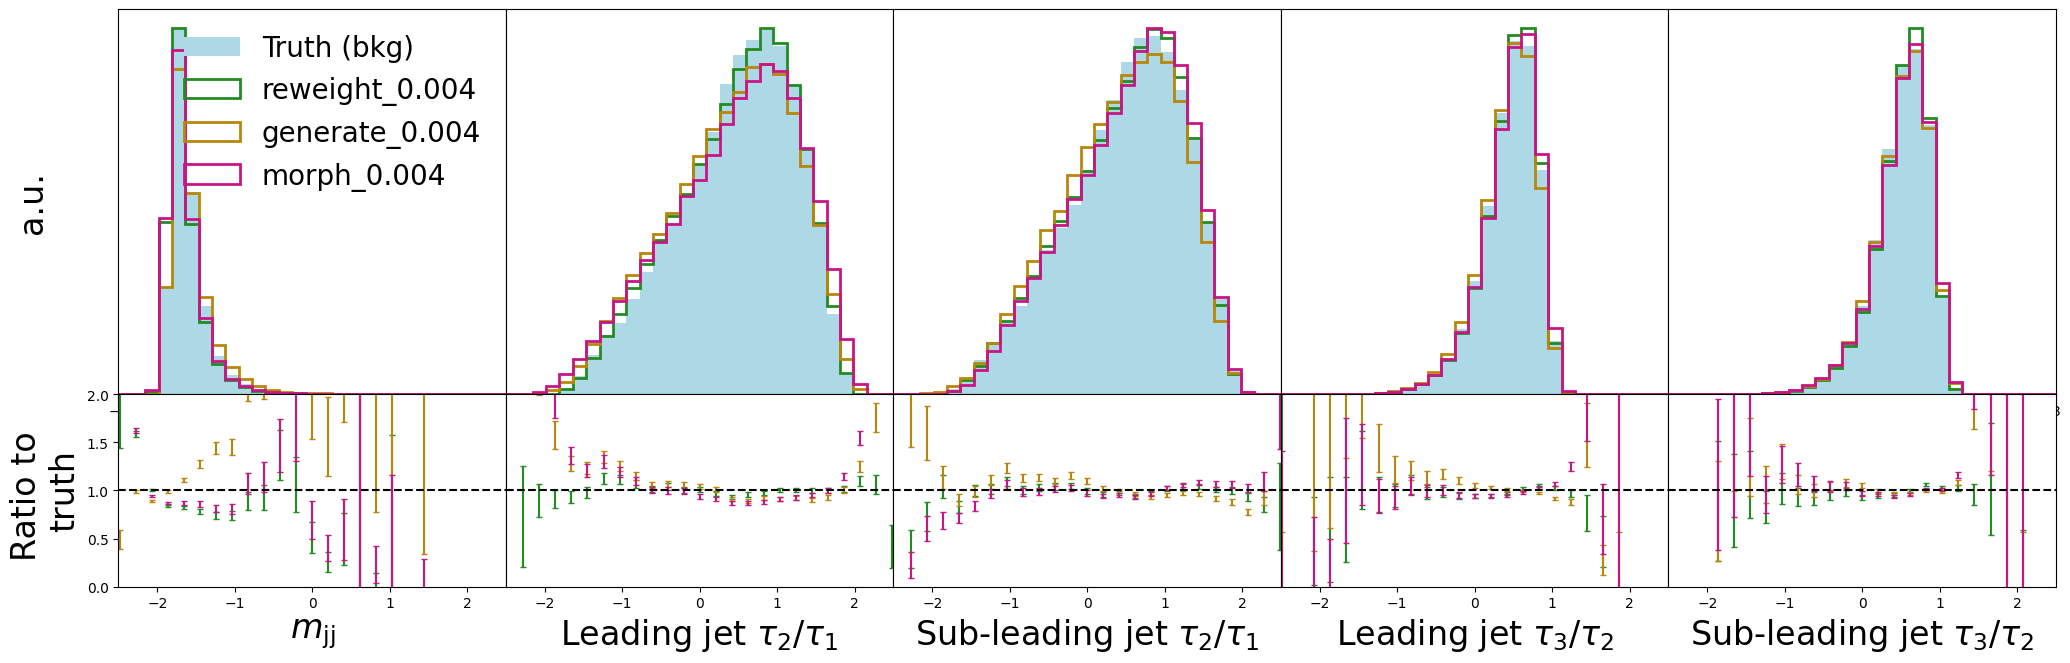

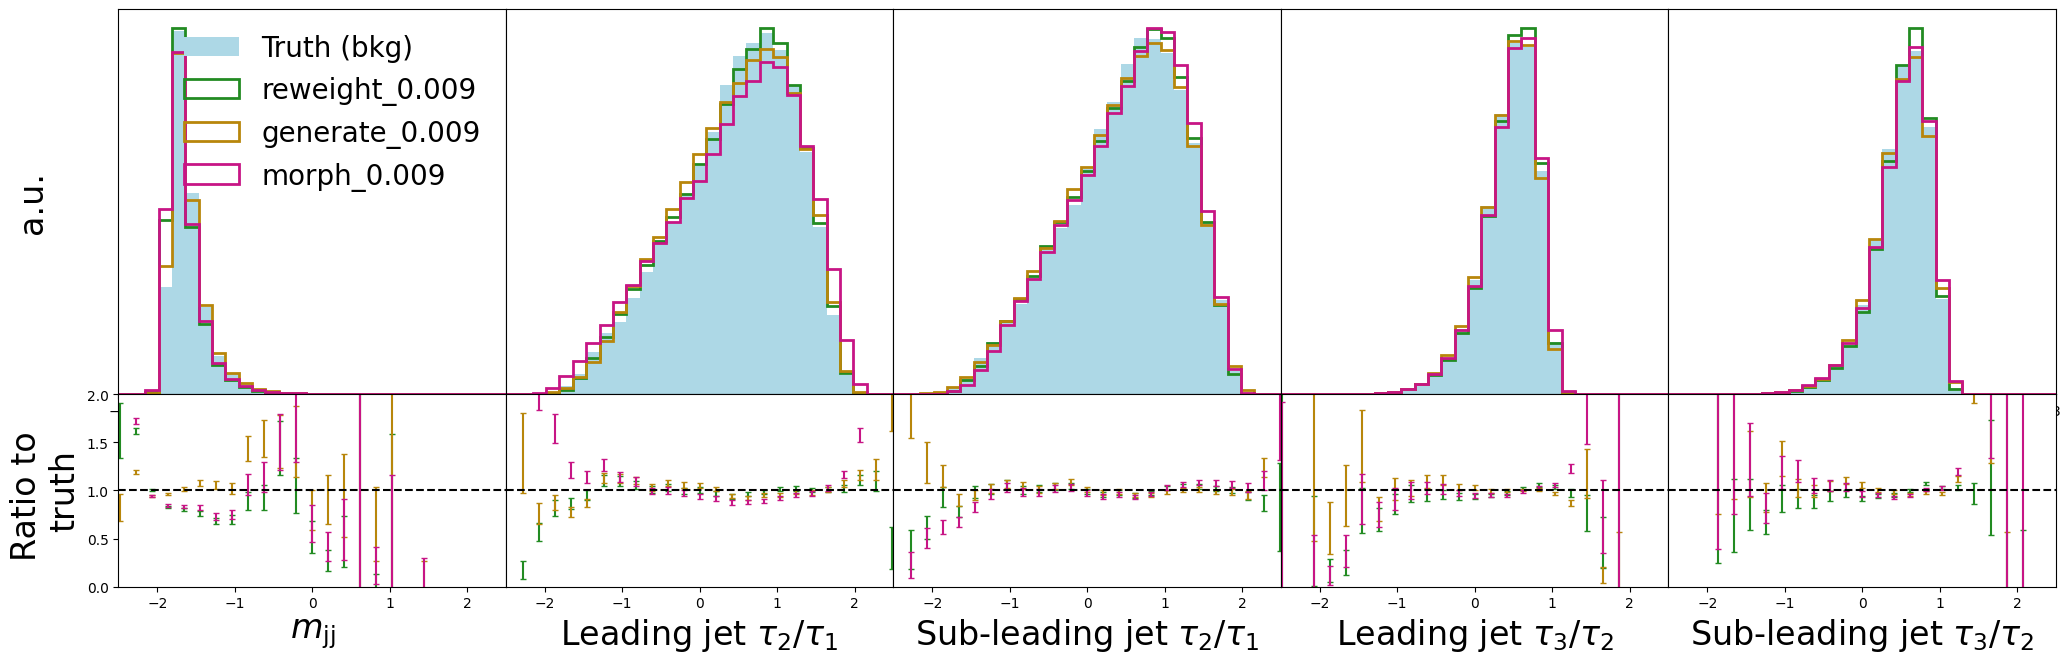

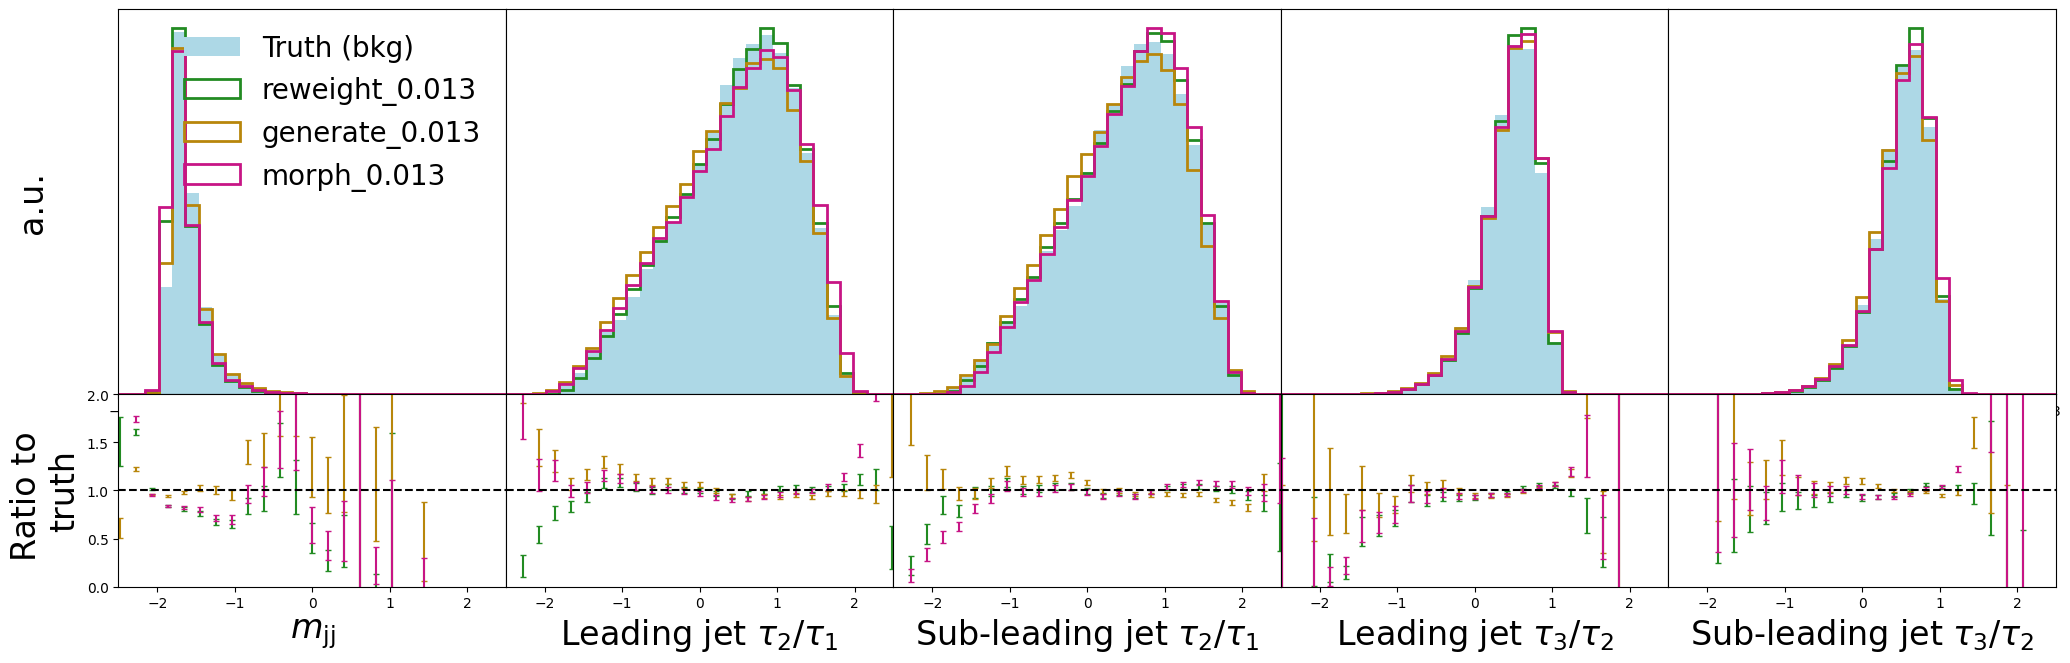

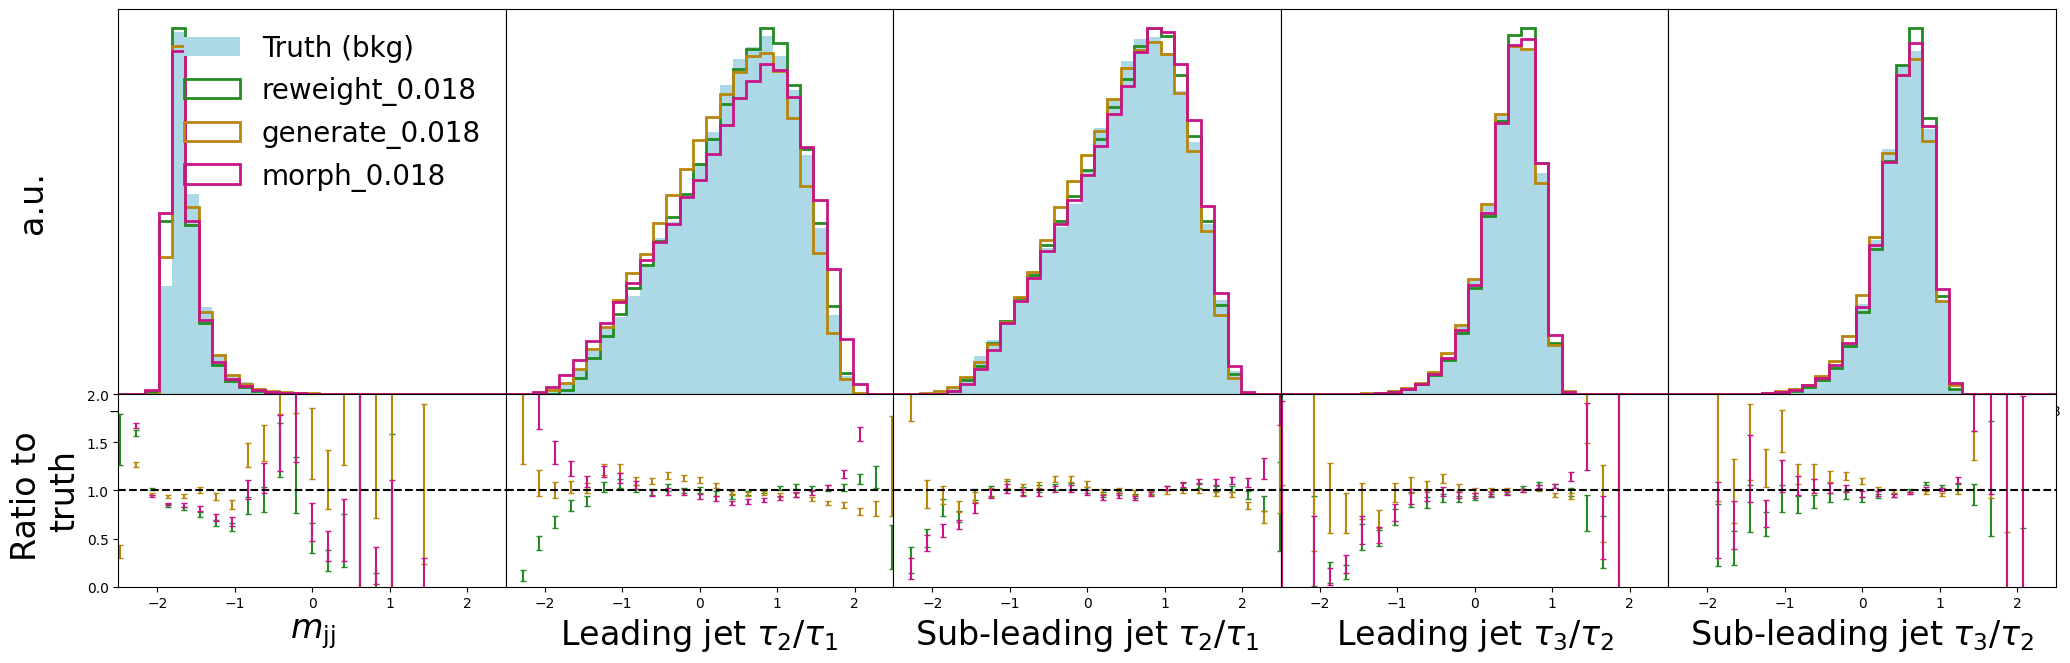

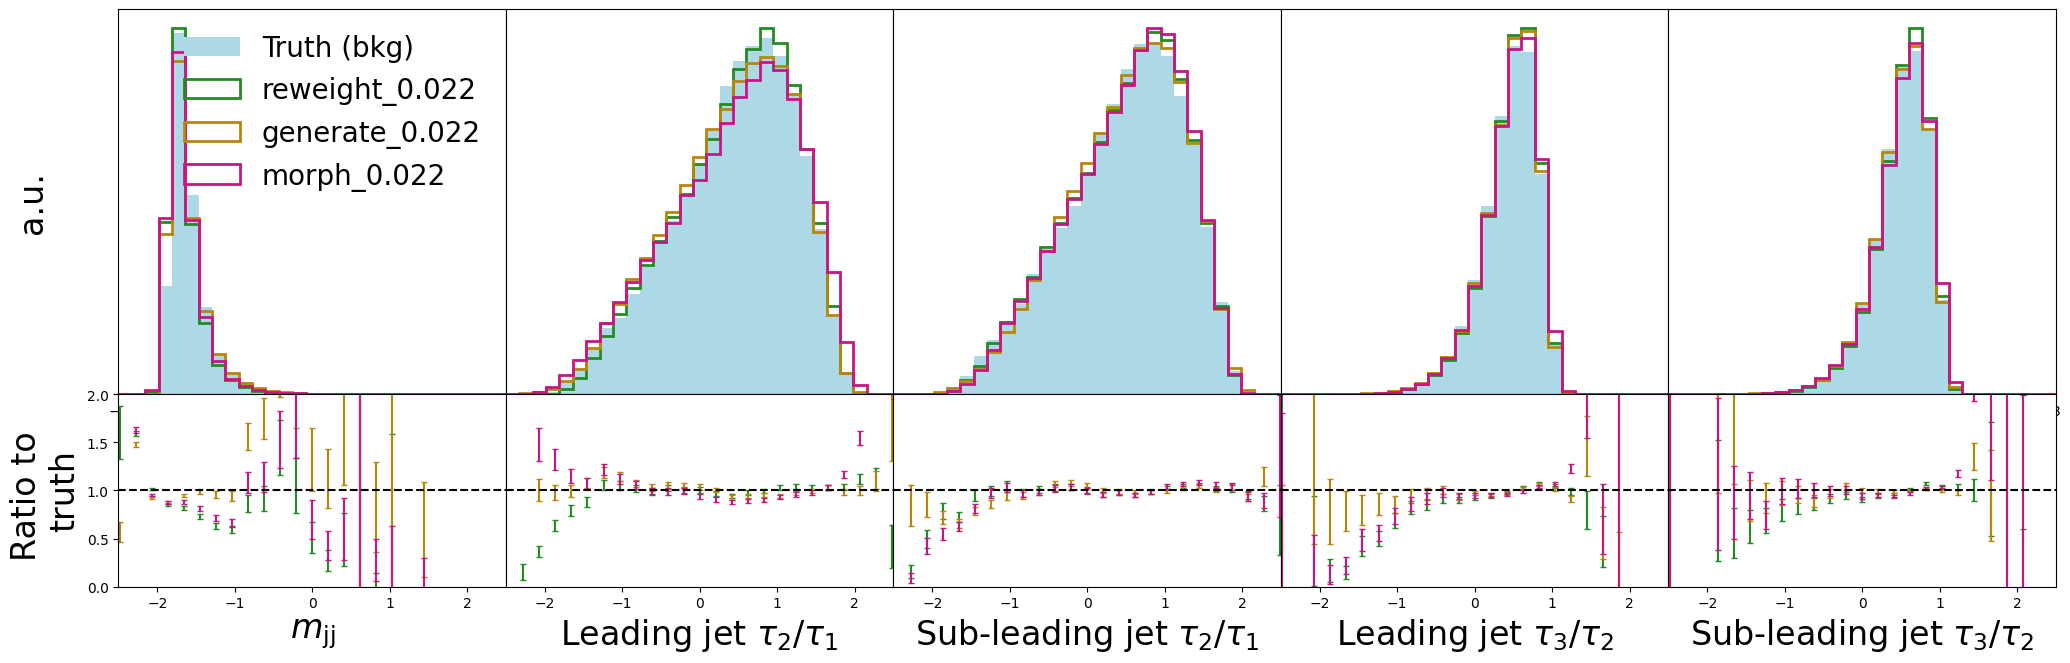

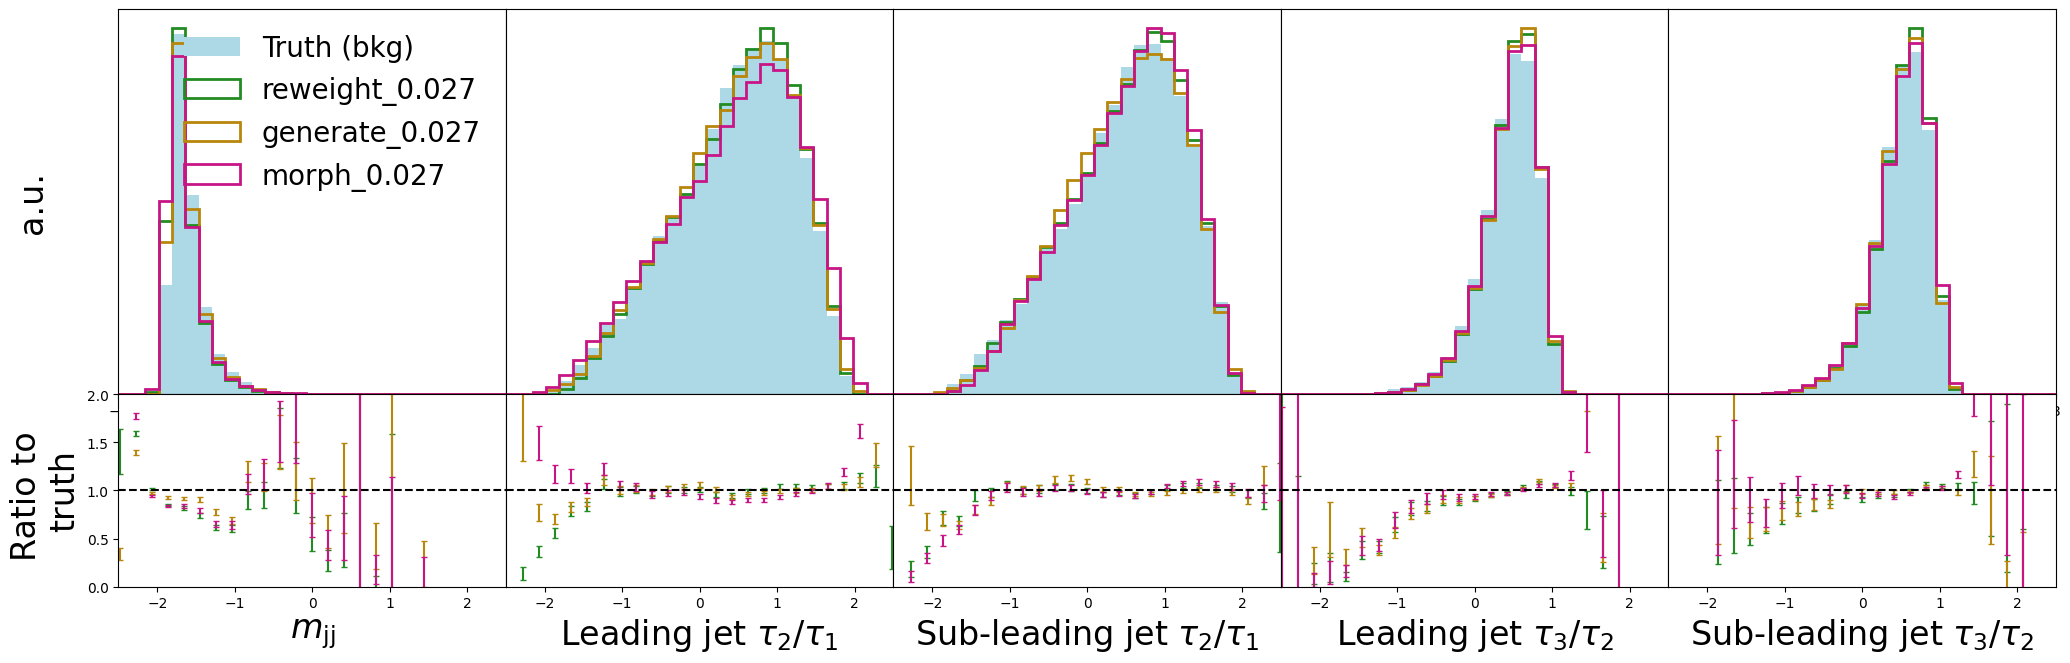

In [54]:
print("SR Closure")
for p in per:
#     keys_to_plot = [f"generate_{p}", f"morph_{p}"]
    keys_to_plot = [f"reweight_{p}", f"generate_{p}",f"morph_{p}"]
    plot_samples(samples_sr_dict, weights_sr_dict, bins, colors_dict, keys_to_plot, xlabel_list, bin_centers, n_features, f1, f2, p)

### CwoLa Training

In [58]:
def plot_CWoLa_loss(train_losses, val_losses, title):

    # Create a figure with two subplots (side by side)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Plot train losses on the left axis
    for i, train in enumerate(train_losses):
        epochs_train = np.arange(1, len(train) + 1)
        ax1.plot(epochs_train, train, label=f'Train Loss (Run {i+1})', alpha=0.7)
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.set_title('Train Loss (All Runs)')
    ax1.grid(True)
    ax1.legend()

    # Plot validation losses on the right axis
    for i, val in enumerate(val_losses):
        epochs_val = np.arange(1, len(val) + 1)
        ax2.plot(epochs_val, val, label=f'Validation Loss (Run {i+1})', linestyle='--', alpha=0.7)
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.set_title('Validation Loss (All Runs)')
    ax2.grid(True)
    ax2.legend()
    plt.title(f"{title}")
    # Adjust layout
    plt.tight_layout()
    plt.show()


In [52]:
gen_seed = 1
n_classifier = 10
# Load Data
models = ['reweight', 'generate', 'morph']
# Loss Path
loss_path = f"{working_dir}/evaluation/seed{gen_seed}"
loss_data = {}
train_loss = {}
val_loss = {}
for p in [0]:
    for model in models:
        for i in range(n_classifier):
            loss_data[f"{model}_loss_{p}_cr_run{i}"] = np.load(f"{loss_path}/loss_data/model_{model}_{p}_cr_run{i}_loss.npz")
            loss_data[f"{model}_loss_{p}_sr_run{i}"] = np.load(f"{loss_path}/loss_data/model_{model}_{p}_sr_run{i}_loss.npz")
            train_loss[f"{model}_tloss_{p}_cr_run{i}"] = loss_data[f"{model}_loss_{p}_cr_run{i}"]["train_loss"]
            val_loss[f"{model}_vloss_{p}_cr_run{i}"] = loss_data[f"{model}_loss_{p}_cr_run{i}"]["val_loss"]
            train_loss[f"{model}_tloss_{p}_sr_run{i}"] = loss_data[f"{model}_loss_{p}_sr_run{i}"]["train_loss"]
            val_loss[f"{model}_vloss_{p}_sr_run{i}"] = loss_data[f"{model}_loss_{p}_sr_run{i}"]["val_loss"]
            

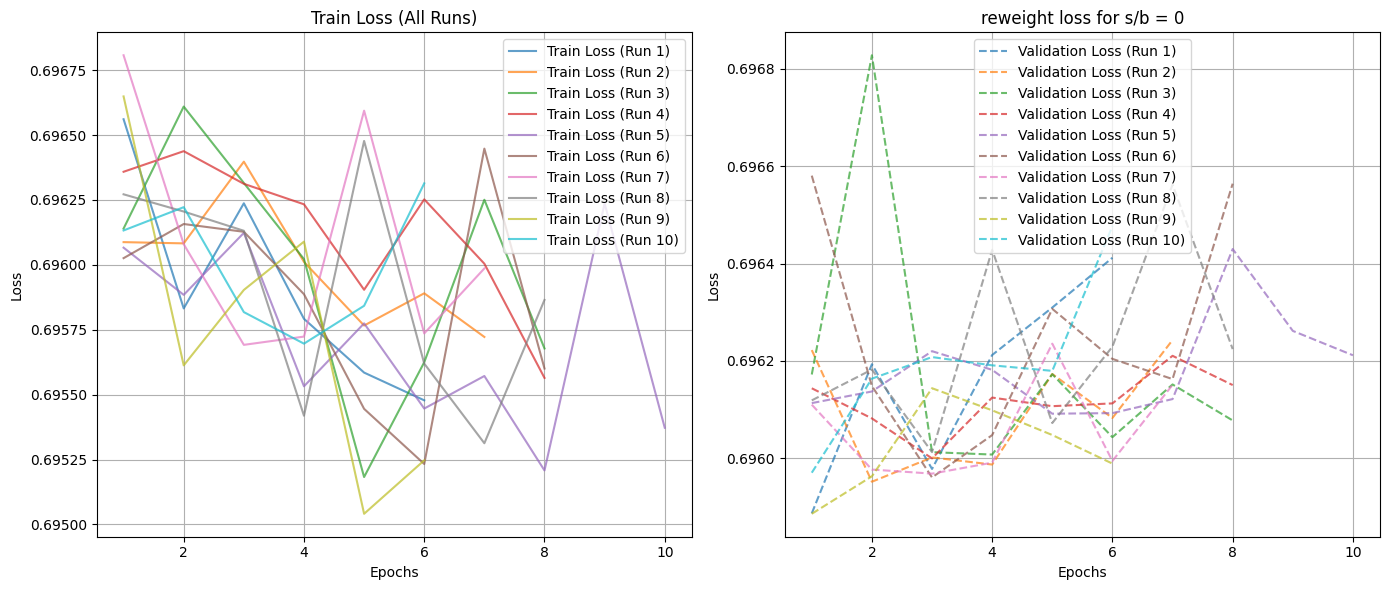

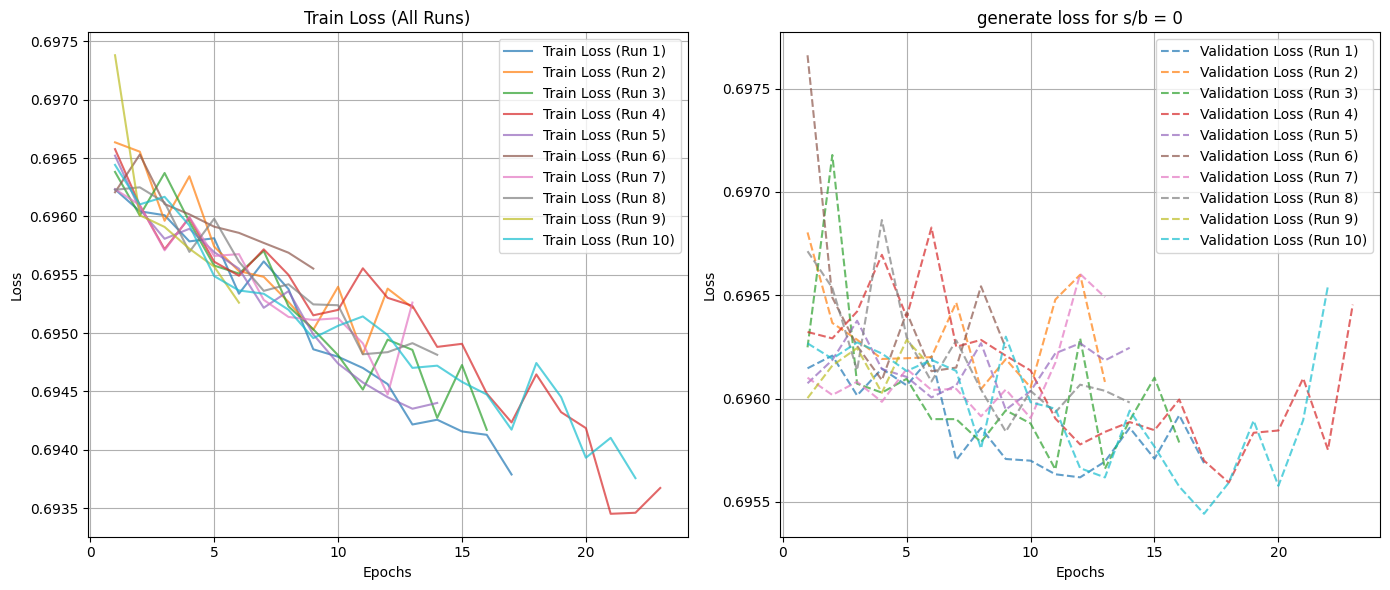

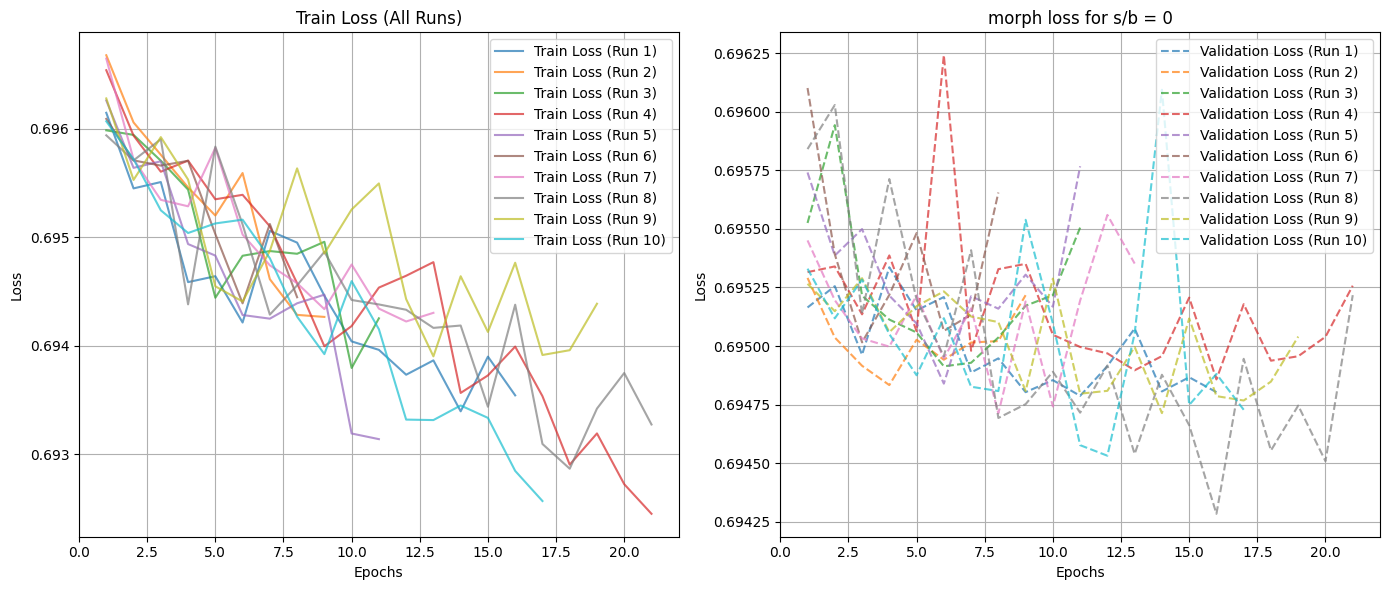

In [59]:
# CR
for p in [0]:
    for model in models:
        train_losses = []
        val_losses = []
        for i in range(n_classifier):
            train_losses.append(train_loss[f"{model}_tloss_{p}_cr_run{i}"])
            val_losses.append(val_loss[f"{model}_vloss_{p}_cr_run{i}"])
            
#         train_losses = np.array(train_losses)
#         print(train_losses)
        plot_CWoLa_loss(train_losses, val_losses, f"{model} loss for s/b = {p}")    


In [9]:
#Get s/b in SR
gen_seed = 1
data_path = f"{working_dir}/data/seed{gen_seed}"
data = {}
for p in per:
    data_file = np.load(f"{data_path}/data_{p}.npz")
    print(data_file['signif'])

0
1
2
2
3
4
5


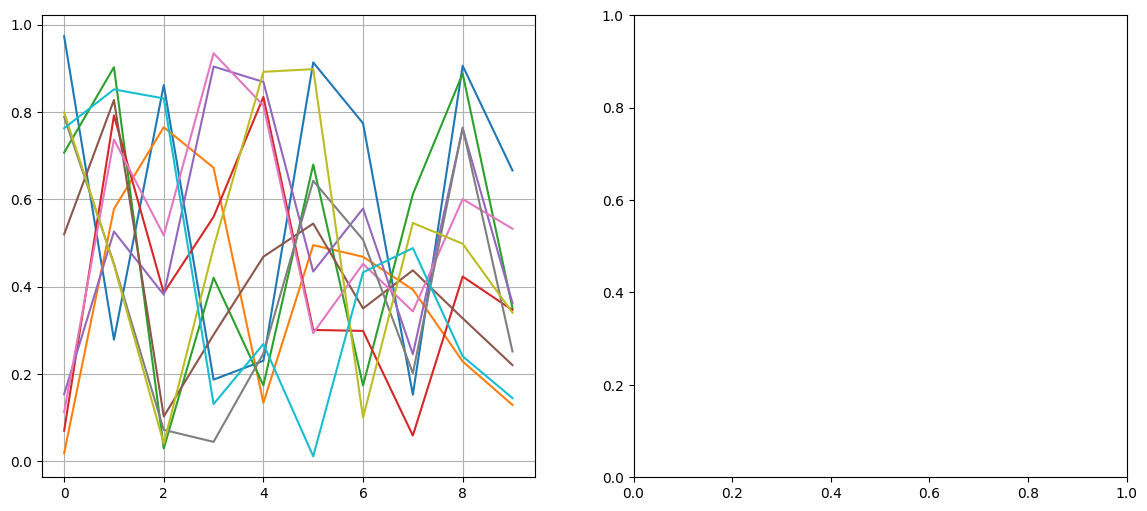

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for i in [np.random.rand(10, 10)]:
    ax1.plot(i)


ax1.grid()
plt.show()